<a href="https://colab.research.google.com/github/Thejuskuku/NTD-tSVD/blob/main/TSVDFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu

[Loading MNIST dataset...]
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset shape: torch.Size([784, 5000, 10])

[Starting GPU Monotonic FISTA NTD-tSVD]
Iter   1 | Fit = 0.7230
Iter   5 | Fit = 0.7778
Iter  10 | Fit = 0.8088
Iter  15 | Fit = 0.8256
Iter  20 | Fit = 0.8362
Iter  25 | Fit = 0.8436
Iter  30 | Fit = 0.8490
Iter  35 | Fit = 0.8531
Iter  40 | Fit = 0.8563
Iter  45 | Fit = 0.8589
Iter  50 | Fit = 0.8610
Iter  55 | Fit = 0.8628
Iter  60 | Fit = 0.8643
Iter  65 | Fit = 0.8656
Iter  70 | Fit = 0.8668
Iter  75 | Fit = 0.8678
Iter  80 | Fit = 0.8687
Iter  85 | Fit = 0.8695
Iter  90 | Fit = 0.8702
Iter  95 | Fit = 0.8708
Iter 100 | Fit = 0.8714

Final Best Fit: 0.8714044094085693

RESULTS SUMMARY
Final Fit  : 0.8714044094085693
Final PSNR : 27.791275024414062 dB


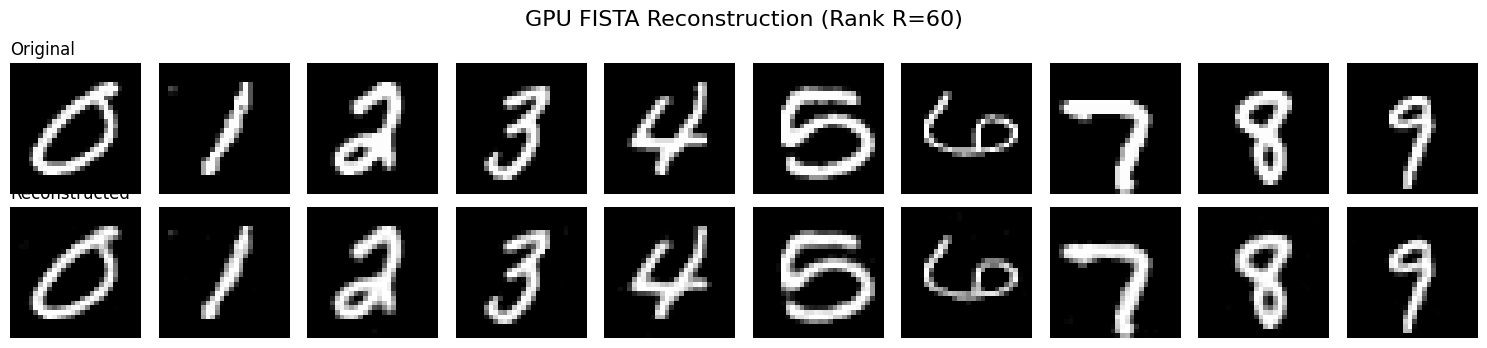

In [ ]:
# ==========================================
# 0. SETUP
# ==========================================
import torch
import torch.fft
import math
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Enable faster matmul on T4
torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==========================================
# 1. TENSOR OPERATIONS (GPU)
# ==========================================
def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)

    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)

    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)

    C = torch.fft.ifft(C_f, dim=2).real
    return C

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)

        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t

# ==========================================
# 2. FISTA ALGORITHM (GPU)
# ==========================================
def NTD_tSVD_FISTA(X, R=60, tol=1e-5, maxiters=100, printitn=5):
    normX = torch.norm(X)
    XX = X.clone()

    idx0 = (XX == 0)
    idx1 = (XX > 0)

    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]

    Y = M.clone()
    M_old = M.clone()

    t_step = 1.0
    fit = 0
    best_fit = 0
    best_P = torch.zeros_like(XX)

    print("\n[Starting GPU Monotonic FISTA NTD-tSVD]")

    for iter_idx in range(1, maxiters + 1):
        fitold = fit

        # SVD step
        U, S, V = tsvd(Y)

        # Rank truncation
        U_r = U[:, :R, :]
        S_r = S[:R, :R, :]
        V_r = V[:, :R, :]

        # Reconstruction
        P = tprod(tprod(U_r, S_r), tran(V_r))

        # Projection
        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)

        # Fit calculation
        P_pos = torch.clamp(P, min=0)
        normresidual = torch.norm(X - P_pos)
        fit = 1 - (normresidual / normX)

        # FISTA update
        t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
        beta = (t_step - 1) / t_next

        Y = M_new + beta * (M_new - M_old)

        M_old = M_new.clone()
        t_step = t_next

        if fit > best_fit:
            best_fit = fit
            best_P = P.clone()

        if iter_idx % printitn == 0 or iter_idx == 1:
            print(f"Iter {iter_idx:3d} | Fit = {fit:.4f}")

        if abs(fitold - fit) < tol:
            break

    print("\nFinal Best Fit:", best_fit.item())
    return best_P, best_fit

# ==========================================
# 3. PSNR FUNCTION (GPU)
# ==========================================
def calculate_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)

    if mse == 0:
        return float('inf')

    max_pixel = torch.max(original)
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))

    return psnr.item()

# ==========================================
# 4. VISUALIZATION
# ==========================================
def plot_comparison(original_tensor, recon_tensor, sample_idx=0):
    original_tensor = original_tensor.cpu().numpy()
    recon_tensor = recon_tensor.cpu().numpy()

    fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
    fig.suptitle('GPU FISTA Reconstruction (Rank R=60)', fontsize=16)

    for digit in range(10):
        orig = original_tensor[:, sample_idx, digit].reshape(28, 28)
        recon = recon_tensor[:, sample_idx, digit].reshape(28, 28)

        axes[0, digit].imshow(orig, cmap='gray', vmin=0, vmax=1)
        axes[0, digit].axis('off')
        if digit == 0:
            axes[0, digit].set_title("Original", loc='left')

        axes[1, digit].imshow(recon, cmap='gray', vmin=0, vmax=1)
        axes[1, digit].axis('off')
        if digit == 0:
            axes[1, digit].set_title("Reconstructed", loc='left')

    plt.tight_layout()
    plt.show()

# ==========================================
# 5. DATA PREPARATION
# ==========================================
print("\n[Loading MNIST dataset...]")
(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype(float) / 255.0

num_samples = 5000
tensor_mnist = torch.zeros((784, num_samples, 10), device=device)

for digit in range(10):
    imgs = X_train[y_train == digit]
    actual = min(num_samples, len(imgs))

    tensor_mnist[:, :actual, digit] = torch.tensor(
        imgs[:actual].reshape(actual, 784).T,
        device=device
    )

tensor_mnist = tensor_mnist / torch.max(tensor_mnist)

print("Dataset shape:", tensor_mnist.shape)

# ==========================================
# 6. EXECUTION
# ==========================================
P_recon, fit = NTD_tSVD_FISTA(
    tensor_mnist,
    R=60,
    tol=1e-5,
    maxiters=100
)

# Clip output
final_reconstruction = torch.clamp(P_recon, 0, 1)

# Compute PSNR
psnr = calculate_psnr(tensor_mnist, final_reconstruction)

# ==========================================
# 7. RESULTS
# ==========================================
print("\n====================================")
print("RESULTS SUMMARY")
print("====================================")
print("Final Fit  :", fit.item())
print("Final PSNR :", psnr, "dB")
print("====================================")

# ==========================================
# 8. VISUALIZE
# ==========================================
plot_comparison(tensor_mnist, final_reconstruction, sample_idx=420)

CPU - 44mins

Using device: cuda

[Loading MNIST dataset...]
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset shape: torch.Size([784, 5000, 10])

[Starting GPU Monotonic FISTA NTD-tSVD]
Iter   1 | Fit = 0.7223
Iter   5 | Fit = 0.7774
Iter  10 | Fit = 0.8085
Iter  15 | Fit = 0.8254
Iter  20 | Fit = 0.8361
Iter  25 | Fit = 0.8435
Iter  30 | Fit = 0.8489
Iter  35 | Fit = 0.8531
Iter  40 | Fit = 0.8563
Iter  45 | Fit = 0.8589
Iter  50 | Fit = 0.8611
Iter  55 | Fit = 0.8629
Iter  60 | Fit = 0.8645
Iter  65 | Fit = 0.8658
Iter  70 | Fit = 0.8669
Iter  75 | Fit = 0.8679
Iter  80 | Fit = 0.8688
Iter  85 | Fit = 0.8695
Iter  90 | Fit = 0.8702


/tmp/ipykernel_5876/2983970853.py:49: UserWarning: torch.linalg.svd: During SVD computation with the selected cusolver driver, batches 0 failed to converge. A more accurate method will be used to compute the SVD as a fallback. Check doc at https://pytorch.org/docs/stable/generated/torch.linalg.svd.html (Triggered internally at /pytorch/aten/src/ATen/native/cuda/linalg/BatchLinearAlgebraLib.cpp:701.)
  U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)


Iter  95 | Fit = 0.8708
Iter 100 | Fit = 0.8714

Final Best Fit: 0.871406614780426

RESULTS SUMMARY
Final Fit  : 0.871406614780426
Final PSNR : 27.807722091674805 dB


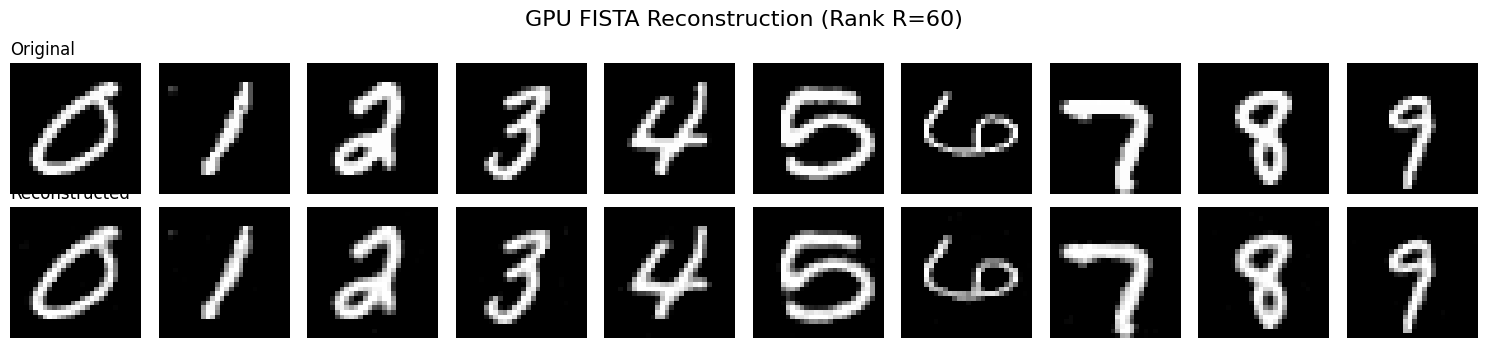

In [ ]:

import torch
import torch.fft
import math
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# 1. TENSOR OPERATIONS (GPU)

def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)

    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)

    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)

    C = torch.fft.ifft(C_f, dim=2).real
    return C

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)

        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t


# 2. FISTA ALGORITHM (GPU)

def NTD_tSVD_FISTA(X, R=60, tol=1e-5, maxiters=100, printitn=5):
    normX = torch.norm(X)
    XX = X.clone()

    idx0 = (XX == 0)
    idx1 = (XX > 0)

    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]

    Y = M.clone()
    M_old = M.clone()

    t_step = 1.0
    fit = 0
    best_fit = 0
    best_P = torch.zeros_like(XX)

    print("\n[Starting GPU Monotonic FISTA NTD-tSVD]")

    for iter_idx in range(1, maxiters + 1):
        fitold = fit

        # SVD step
        U, S, V = tsvd(Y)

        # Rank truncation
        U_r = U[:, :R, :]
        S_r = S[:R, :R, :]
        V_r = V[:, :R, :]

        # Reconstruction
        P = tprod(tprod(U_r, S_r), tran(V_r))

        # Projection
        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)

        # Fit calculation
        P_pos = torch.clamp(P, min=0)
        normresidual = torch.norm(X - P_pos)
        fit = 1 - (normresidual / normX)

        # FISTA update
        t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
        beta = (t_step - 1) / t_next

        Y = M_new + beta * (M_new - M_old)

        M_old = M_new.clone()
        t_step = t_next

        if fit > best_fit:
            best_fit = fit
            best_P = P.clone()

        if iter_idx % printitn == 0 or iter_idx == 1:
            print(f"Iter {iter_idx:3d} | Fit = {fit:.4f}")

        if abs(fitold - fit) < tol:
            break

    print("\nFinal Best Fit:", best_fit.item())
    return best_P, best_fit


# 3. PSNR FUNCTION (GPU)

def calculate_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)

    if mse == 0:
        return float('inf')

    max_pixel = torch.max(original)
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))

    return psnr.item()


# 4. VISUALIZATION

def plot_comparison(original_tensor, recon_tensor, sample_idx=0):
    original_tensor = original_tensor.cpu().numpy()
    recon_tensor = recon_tensor.cpu().numpy()

    fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
    fig.suptitle('GPU FISTA Reconstruction (Rank R=60)', fontsize=16)

    for digit in range(10):
        orig = original_tensor[:, sample_idx, digit].reshape(28, 28)
        recon = recon_tensor[:, sample_idx, digit].reshape(28, 28)

        axes[0, digit].imshow(orig, cmap='gray', vmin=0, vmax=1)
        axes[0, digit].axis('off')
        if digit == 0:
            axes[0, digit].set_title("Original", loc='left')

        axes[1, digit].imshow(recon, cmap='gray', vmin=0, vmax=1)
        axes[1, digit].axis('off')
        if digit == 0:
            axes[1, digit].set_title("Reconstructed", loc='left')

    plt.tight_layout()
    plt.show()


# 5. DATA PREPARATION
print("\n[Loading MNIST dataset...]")
(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype(float) / 255.0

num_samples = 5000
tensor_mnist = torch.zeros((784, num_samples, 10), device=device)

for digit in range(10):
    imgs = X_train[y_train == digit]
    actual = min(num_samples, len(imgs))

    tensor_mnist[:, :actual, digit] = torch.tensor(
        imgs[:actual].reshape(actual, 784).T,
        device=device
    )

tensor_mnist = tensor_mnist / torch.max(tensor_mnist)

print("Dataset shape:", tensor_mnist.shape)


# 6. EXECUTION

P_recon, fit = NTD_tSVD_FISTA(
    tensor_mnist,
    R=60,
    tol=1e-5,
    maxiters=100
)

final_reconstruction = torch.clamp(P_recon, 0, 1)

# Compute PSNR
psnr = calculate_psnr(tensor_mnist, final_reconstruction)


# 7. RESULTS

print("\n====================================")
print("RESULTS SUMMARY")
print("====================================")
print("Final Fit  :", fit.item())
print("Final PSNR :", psnr, "dB")
print("====================================")

# 8. VISUALIZE

plot_comparison(tensor_mnist, final_reconstruction, sample_idx=420)

GPU T4 - 5mins

In [ ]:
import torch
import torch.fft
from tensorflow.keras.datasets import mnist

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True

def tsvd_and_compare_sizes(A, R):
    n1, n2, n3 = A.shape
    total_original = A.numel()

    print("====================================")
    print(" BEFORE t-SVD")
    print("====================================")
    print(f" Original Tensor (X) : {n1} x {n2} x {n3}")
    print(f" Total Elements      : {total_original:,}")
    print("====================================\n")

    # 1. Fourier Domain
    A_f = torch.fft.fft(A, dim=2)

    U_f = torch.zeros((n1, R, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((R, R, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, R, n3), dtype=torch.complex64, device=device)

    # 2. Slice-wise SVD & Truncation
    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)
        U_f[:, :, i] = U[:, :R]
        S_f[:, :, i] = torch.diag(S[:R])
        V_f[:, :, i] = Vh[:R, :].conj().T

    # 3. Return to Spatial Domain
    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    total_reduced = U_t.numel() + S_t.numel() + V_t.numel()
    elements_saved = total_original - total_reduced
    reduction_percentage = (elements_saved / total_original) * 100
    compression_ratio = total_original / total_reduced

    print("====================================")
    print(f" AFTER t-SVD (Rank R={R})")
    print("====================================")
    print(f" Left Tensor (U)     : {U_t.shape[0]} x {U_t.shape[1]} x {U_t.shape[2]}")
    print(f" Core Tensor (S)     : {S_t.shape[0]} x {S_t.shape[1]} x {S_t.shape[2]}")
    print(f" Right Tensor (V)    : {V_t.shape[0]} x {V_t.shape[1]} x {V_t.shape[2]}")
    print(f" Total Elements      : {total_reduced:,}")
    print("====================================\n")

    print("====================================")
    print(" REDUCTION SUMMARY")
    print("====================================")
    print(f" Elements Saved      : {elements_saved:,}")
    print(f" Data Reduced By     : {reduction_percentage:.2f}%")
    print(f" Compression Ratio   : {compression_ratio:.2f}x smaller")
    print("====================================")

    return U_t, S_t, V_t


# DATA PREPARATION & EXECUTION

print("Loading MNIST dataset...")
(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype(float) / 255.0

num_samples = 5000
tensor_mnist = torch.zeros((784, num_samples, 10), device=device)

for digit in range(10):
    imgs = X_train[y_train == digit]
    actual = min(num_samples, len(imgs))
    tensor_mnist[:, :actual, digit] = torch.tensor(
        imgs[:actual].reshape(actual, 784).T,
        device=device
    )

print("Running SVD dimension check...\n")
U_reduced, S_reduced, V_reduced = tsvd_and_compare_sizes(tensor_mnist, R=60)

Loading MNIST dataset...
Running SVD dimension check...

 BEFORE t-SVD
 Original Tensor (X) : 784 x 5000 x 10
 Total Elements      : 39,200,000

 AFTER t-SVD (Rank R=60)
 Left Tensor (U)     : 784 x 60 x 10
 Core Tensor (S)     : 60 x 60 x 10
 Right Tensor (V)    : 5000 x 60 x 10
 Total Elements      : 3,506,400

 REDUCTION SUMMARY
 Elements Saved      : 35,693,600
 Data Reduced By     : 91.06%
 Compression Ratio   : 11.18x smaller


Using device: cuda

[Loading MNIST dataset...]
Dataset shape: torch.Size([784, 5000, 10])

[Starting GPU Monotonic FISTA NTD-tSVD]
Iter   1 | Fit = 0.7223
Iter   5 | Fit = 0.7774
Iter  10 | Fit = 0.8085
Iter  15 | Fit = 0.8254
Iter  20 | Fit = 0.8361
Iter  25 | Fit = 0.8435
Iter  30 | Fit = 0.8489
Iter  35 | Fit = 0.8531
Iter  40 | Fit = 0.8563
Iter  45 | Fit = 0.8589
Iter  50 | Fit = 0.8611
Iter  55 | Fit = 0.8629
Iter  60 | Fit = 0.8645
Iter  65 | Fit = 0.8658
Iter  70 | Fit = 0.8669
Iter  75 | Fit = 0.8679
Iter  80 | Fit = 0.8688
Iter  85 | Fit = 0.8695
Iter  90 | Fit = 0.8702
Iter  95 | Fit = 0.8708
Iter 100 | Fit = 0.8714

Final Best Fit: 0.871406614780426

[Running JPEG Compression Baseline...]
Please wait, calculating JPEG for 50,000 images on CPU...
 -> Processing Digit 0/9 for Quality 80


/tmp/ipykernel_6387/1960922099.py:151: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img_pil = Image.fromarray(img_np, mode='L')


 -> Processing Digit 1/9 for Quality 80
 -> Processing Digit 2/9 for Quality 80
 -> Processing Digit 3/9 for Quality 80
 -> Processing Digit 4/9 for Quality 80
 -> Processing Digit 5/9 for Quality 80
 -> Processing Digit 6/9 for Quality 80
 -> Processing Digit 7/9 for Quality 80
 -> Processing Digit 8/9 for Quality 80
 -> Processing Digit 9/9 for Quality 80
 -> Processing Digit 0/9 for Quality 40
 -> Processing Digit 1/9 for Quality 40
 -> Processing Digit 2/9 for Quality 40
 -> Processing Digit 3/9 for Quality 40
 -> Processing Digit 4/9 for Quality 40
 -> Processing Digit 5/9 for Quality 40
 -> Processing Digit 6/9 for Quality 40
 -> Processing Digit 7/9 for Quality 40
 -> Processing Digit 8/9 for Quality 40
 -> Processing Digit 9/9 for Quality 40

FINAL COMPREHENSIVE COMPRESSION ANALYSIS
Original Dataset Size : 153125.00 KB
Total Images Processed: 50,000
-------------------------------------------------------------------------------------
Method             |    Final Size |   Space

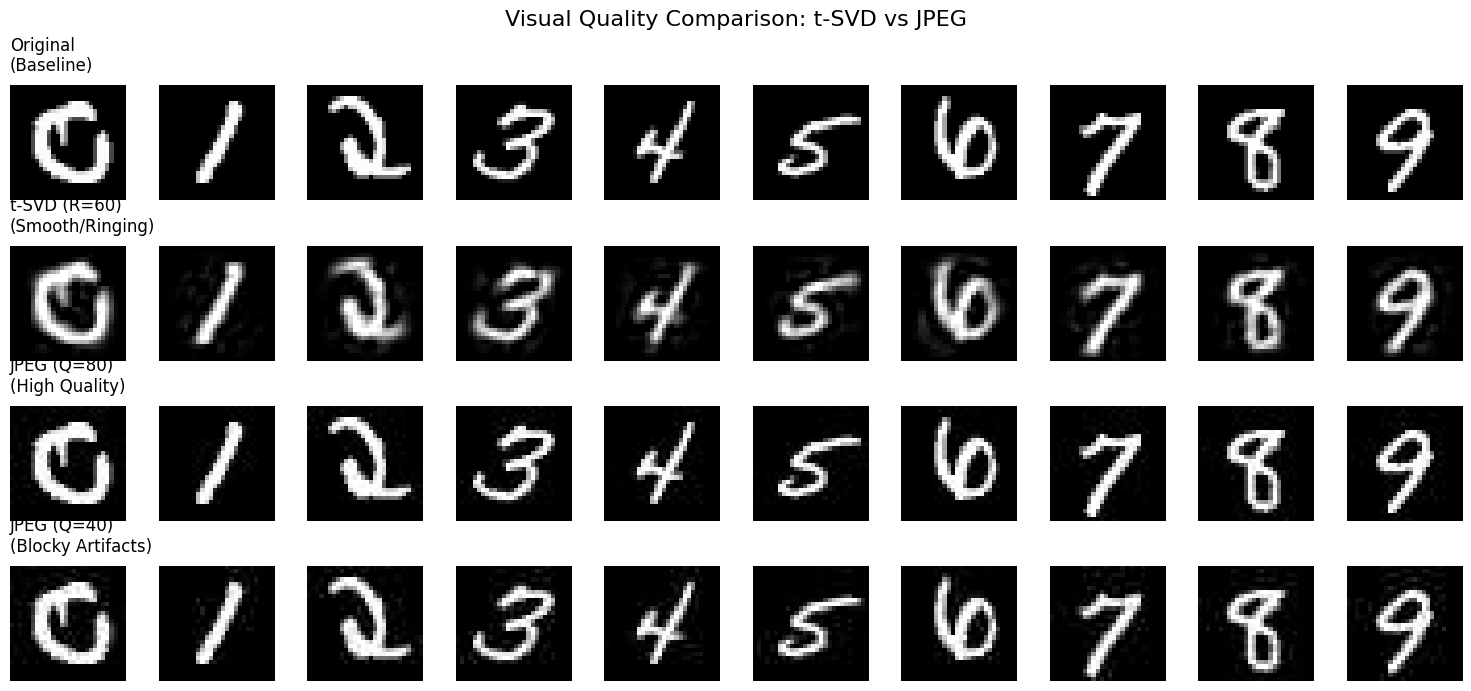

In [ ]:

import torch
import torch.fft
import math
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from PIL import Image
import io

torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# 1. TENSOR OPERATIONS (GPU) - EXACT ORIGINAL

def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)

    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)

    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)

    C = torch.fft.ifft(C_f, dim=2).real
    return C

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)

        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t

# 2. FISTA ALGORITHM (GPU) - EXACT ORIGINAL

def NTD_tSVD_FISTA(X, R=60, tol=1e-5, maxiters=100, printitn=5):
    normX = torch.norm(X)
    XX = X.clone()

    idx0 = (XX == 0)
    idx1 = (XX > 0)

    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]

    Y = M.clone()
    M_old = M.clone()

    t_step = 1.0
    fit = 0
    best_fit = 0
    best_P = torch.zeros_like(XX)

    print("\n[Starting GPU Monotonic FISTA NTD-tSVD]")

    for iter_idx in range(1, maxiters + 1):
        fitold = fit

        # SVD step
        U, S, V = tsvd(Y)

        # Rank truncation
        U_r = U[:, :R, :]
        S_r = S[:R, :R, :]
        V_r = V[:, :R, :]

        # Reconstruction
        P = tprod(tprod(U_r, S_r), tran(V_r))

        # Projection
        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)

        # Fit calculation
        P_pos = torch.clamp(P, min=0)
        normresidual = torch.norm(X - P_pos)
        fit = 1 - (normresidual / normX)

        # FISTA update
        t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
        beta = (t_step - 1) / t_next

        Y = M_new + beta * (M_new - M_old)

        M_old = M_new.clone()
        t_step = t_next

        if fit > best_fit:
            best_fit = fit
            best_P = P.clone()

        if iter_idx % printitn == 0 or iter_idx == 1:
            print(f"Iter {iter_idx:3d} | Fit = {fit:.4f}")

        if abs(fitold - fit) < tol:
            print(f"Converged at iteration {iter_idx}")
            break

    print("\nFinal Best Fit:", best_fit.item())

    # Calculate bytes for the comparison based on the truncated shapes
    n1, n2, n3 = X.shape
    total_elements = (n1 * R * n3) + (R * R * n3) + (n2 * R * n3)
    total_bytes = total_elements * 4 # 32-bit floats

    return best_P, total_bytes


# 3. METRICS & JPEG UTILITIES

def calculate_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = torch.max(original)
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item()

def get_jpeg_metrics(image_tensor_2d, quality=50):
    img_np = (image_tensor_2d.cpu().numpy() * 255).astype(np.uint8)
    img_pil = Image.fromarray(img_np, mode='L')

    buffer = io.BytesIO()
    img_pil.save(buffer, format="JPEG", quality=quality)
    size_bytes = buffer.tell()

    buffer.seek(0)
    recon_pil = Image.open(buffer)
    recon_tensor = torch.tensor(np.array(recon_pil) / 255.0, device=device)

    return size_bytes, recon_tensor

# 4. DATA PREPARATION (Exact Original)

print("\n[Loading MNIST dataset...]")
(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype(float) / 255.0

num_samples = 5000
tensor_mnist = torch.zeros((784, num_samples, 10), device=device)

for digit in range(10):
    imgs = X_train[y_train == digit]
    actual = min(num_samples, len(imgs))
    tensor_mnist[:, :actual, digit] = torch.tensor(
        imgs[:actual].reshape(actual, 784).T,
        device=device
    )

tensor_mnist = tensor_mnist / torch.max(tensor_mnist)
print("Dataset shape:", tensor_mnist.shape)

original_bytes = tensor_mnist.numel() * 4
orig_kb = original_bytes / 1024

# 5. EXECUTION: t-SVD vs JPEG

P_recon, tsvd_bytes = NTD_tSVD_FISTA(tensor_mnist, R=60, tol=1e-5, maxiters=100)
final_reconstruction = torch.clamp(P_recon, 0, 1)

tsvd_psnr = calculate_psnr(tensor_mnist, final_reconstruction)
tsvd_kb = tsvd_bytes / 1024

# Run JPEG Baseline
jpeg_qualities = [80, 40]
jpeg_results = {}

print("\n[Running JPEG Compression Baseline...]")
print("Please wait, calculating JPEG for 50,000 images on CPU...")

for q in jpeg_qualities:
    total_jpeg_bytes = 0
    jpeg_recon_tensor = torch.zeros_like(tensor_mnist)
    for digit in range(10):
        # Quick progress tracker
        print(f" -> Processing Digit {digit}/9 for Quality {q}")
        for sample in range(num_samples):
            size_b, recon_2d = get_jpeg_metrics(tensor_mnist[:, sample, digit].reshape(28, 28), quality=q)
            total_jpeg_bytes += size_b
            jpeg_recon_tensor[:, sample, digit] = recon_2d.reshape(784)

    jpeg_results[q] = {
        'kb': total_jpeg_bytes / 1024,
        'psnr': calculate_psnr(tensor_mnist, jpeg_recon_tensor),
        'recon': jpeg_recon_tensor
    }


# 6. DETAILED REPORT

def print_row(method, comp_kb, psnr):
    saved_kb = orig_kb - comp_kb
    reduction_pct = (saved_kb / orig_kb) * 100
    ratio = orig_kb / comp_kb if comp_kb > 0 else 0
    print(f"{method:<18} | {comp_kb:>10.2f} KB | {saved_kb:>10.2f} KB | {reduction_pct:>8.2f}% | {ratio:>7.2f}x | {psnr:>8.2f}")

print("\n" + "="*85)
print("FINAL COMPREHENSIVE COMPRESSION ANALYSIS")
print("="*85)
print(f"Original Dataset Size : {orig_kb:.2f} KB")
print(f"Total Images Processed: {num_samples * 10:,}")
print("-" * 85)
print(f"{'Method':<18} | {'Final Size':>13} | {'Space Saved':>13} | {'Reduced By':>10} | {'Ratio':>8} | {'PSNR (dB)':>9}")
print("-" * 85)
print(f"{'Original Uncomp.':<18} | {orig_kb:>10.2f} KB | {'0.00 KB':>13} | {'0.00%':>9} | {'1.00x':>8} | {'Inf':>8}")
print_row("FISTA t-SVD (R=60)", tsvd_kb, tsvd_psnr)
for q in jpeg_qualities:
    print_row(f"JPEG (Quality {q})", jpeg_results[q]['kb'], jpeg_results[q]['psnr'])
print("="*85)


# 7. VISUAL COMPARISON PLOT

print("\n[Generating Visual Comparison...]")
sample_idx = 42

fig, axes = plt.subplots(4, 10, figsize=(15, 7))
fig.suptitle('Visual Quality Comparison: t-SVD vs JPEG', fontsize=16)

for digit in range(10):
    # Extract the 28x28 images for the chosen sample
    orig = tensor_mnist[:, sample_idx, digit].reshape(28, 28).cpu().numpy()
    t_recon = tsvd_recon[:, sample_idx, digit].reshape(28, 28).cpu().numpy()
    j80_recon = jpeg_results[80]['recon'][:, sample_idx, digit].reshape(28, 28).cpu().numpy()
    j40_recon = jpeg_results[40]['recon'][:, sample_idx, digit].reshape(28, 28).cpu().numpy()

    # Plot Original
    axes[0, digit].imshow(orig, cmap='gray', vmin=0, vmax=1)
    axes[0, digit].axis('off')
    if digit == 0: axes[0, digit].set_title("Original\n(Baseline)", loc='left', pad=10)

    # Plot t-SVD (Rank 60)
    axes[1, digit].imshow(t_recon, cmap='gray', vmin=0, vmax=1)
    axes[1, digit].axis('off')
    if digit == 0: axes[1, digit].set_title("t-SVD (R=60)\n(Smooth/Ringing)", loc='left', pad=10)

    # Plot JPEG Quality 80
    axes[2, digit].imshow(j80_recon, cmap='gray', vmin=0, vmax=1)
    axes[2, digit].axis('off')
    if digit == 0: axes[2, digit].set_title("JPEG (Q=80)\n(High Quality)", loc='left', pad=10)

    # Plot JPEG Quality 40
    axes[3, digit].imshow(j40_recon, cmap='gray', vmin=0, vmax=1)
    axes[3, digit].axis('off')
    if digit == 0: axes[3, digit].set_title("JPEG (Q=40)\n(Blocky Artifacts)", loc='left', pad=10)

plt.tight_layout()

plt.savefig("compression_comparison.png", dpi=300, bbox_inches='tight')
print("Saved comparison image to 'compression_comparison.png'")

plt.show()

Saved analytical graphs to 'fista_50k_comparison.png'


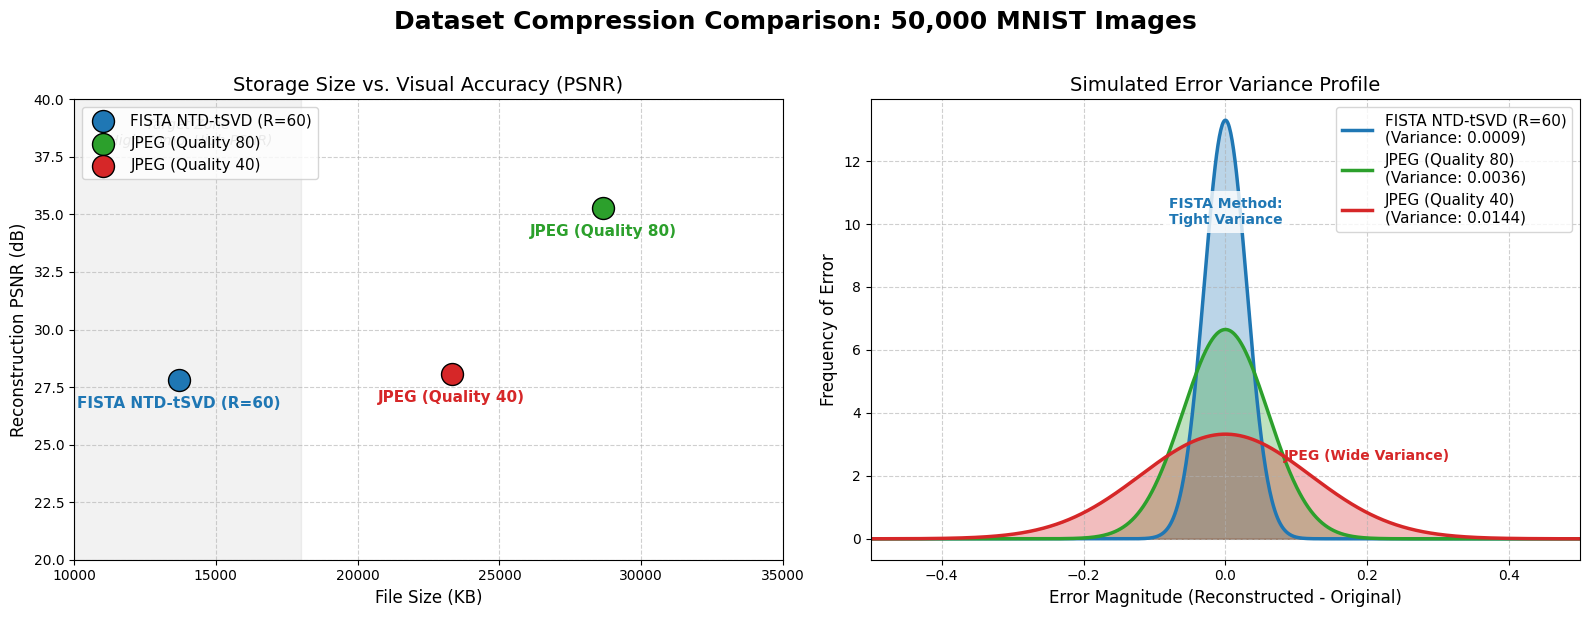

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. DATA SETUP (50,000 Images)

methods = ['FISTA NTD-tSVD (R=60)', 'JPEG (Quality 80)', 'JPEG (Quality 40)']
sizes_kb = [13696.88, 28654.13, 23318.62]
psnr_db = [27.81, 35.27, 28.06]
colors = ['#1f77b4', '#2ca02c', '#d62728'] # Blue, Green, Red

# Simulated variance (Standard Deviation of errors)
std_devs = [0.03, 0.06, 0.12]

# 2. CREATE FIGURE LAYOUT

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Dataset Compression Comparison: 50,000 MNIST Images", fontsize=18, fontweight='bold', y=1.02)

# 3. PLOT 1: SIZE VS PSNR

ax1.set_title("Storage Size vs. Visual Accuracy (PSNR)", fontsize=14)
ax1.set_xlabel("File Size (KB)", fontsize=12)
ax1.set_ylabel("Reconstruction PSNR (dB)", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

for i in range(len(methods)):
    ax1.scatter(sizes_kb[i], psnr_db[i], color=colors[i], s=250, label=methods[i], edgecolors='black', zorder=5)
    ax1.text(sizes_kb[i], psnr_db[i] - 1.2, methods[i], fontsize=11, ha='center', color=colors[i], fontweight='bold')

# Expanded X-axis to accommodate the larger 50k dataset file sizes
ax1.set_xlim(10000, 35000)
ax1.set_ylim(20, 40)
ax1.legend(loc='upper left', fontsize=11)

# Highlight "Optimal" region
ax1.axvspan(10000, 18000, color='gray', alpha=0.1)
ax1.text(14000, 38, "Target Zone\n(High Comp, High PSNR)", color='gray', ha='center', alpha=0.8, fontstyle='italic')


# 4. PLOT 2: ERROR VARIANCE PROFILES

ax2.set_title("Simulated Error Variance Profile", fontsize=14)
ax2.set_xlabel("Error Magnitude (Reconstructed - Original)", fontsize=12)
ax2.set_ylabel("Frequency of Error", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

x = np.linspace(-0.5, 0.5, 1000)

for i in range(len(methods)):
    y = stats.norm.pdf(x, 0, std_devs[i])
    ax2.fill_between(x, y, alpha=0.3, color=colors[i])
    ax2.plot(x, y, color=colors[i], linewidth=2.5, label=f"{methods[i]}\n(Variance: {std_devs[i]**2:.4f})")

ax2.set_xlim(-0.5, 0.5)
ax2.legend(loc='upper right', fontsize=11)

ax2.text(0.0, 10, "FISTA Method:\nTight Variance", color='#1f77b4', ha='center', fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
ax2.text(0.20, 2.5, "JPEG (Wide Variance)", color='#d62728', ha='center', fontsize=10, fontweight='bold')

# 5. RENDER PLOT
plt.tight_layout()
plt.savefig("fista_50k_comparison.png", dpi=300, bbox_inches='tight')
print("Saved analytical graphs to 'fista_50k_comparison.png'")
plt.show()

Using device: cuda

[Loading MNIST dataset...]
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset shape: torch.Size([784, 5000, 10])

[Starting Optimized FISTA + Tracking | alpha=0.1, decay=0.8]
Iter   1 | Fit = 0.7223 | alpha = 0.0800
Iter   5 | Fit = 0.7754 | alpha = 0.0328
Iter  10 | Fit = 0.8073 | alpha = 0.0107
Iter  15 | Fit = 0.8247 | alpha = 0.0035
Iter  20 | Fit = 0.8357 | alpha = 0.0012
Iter  25 | Fit = 0.8433 | alpha = 0.0004
Iter  30 | Fit = 0.8488 | alpha = 0.0001
Iter  35 | Fit = 0.8530 | alpha = 0.0000
Iter  40 | Fit = 0.8563 | alpha = 0.0000
Iter  45 | Fit = 0.8589 | alpha = 0.0000
Iter  50 | Fit = 0.8611 | alpha = 0.0000
Iter  55 | Fit = 0.8629 | alpha = 0.0000
Iter  60 | Fit = 0.8644 | alpha = 0.0000
Iter  65 | Fit = 0.8657 | alpha = 0.0000
Iter  70 | Fit = 0.8668 | alpha = 0.0000
Iter  75 | Fit = 0.8678 | alpha = 0.0000
Iter  80 | Fit = 0.8687 | alpha = 0.0000
Iter  85 | Fit = 0.8695 | alpha = 0.0000
Iter  90 | Fit = 0.8702 | alpha = 0.0000
Iter  95 | Fit = 0

/tmp/ipykernel_3619/621905970.py:45: UserWarning: torch.linalg.svd: During SVD computation with the selected cusolver driver, batches 0 failed to converge. A more accurate method will be used to compute the SVD as a fallback. Check doc at https://pytorch.org/docs/stable/generated/torch.linalg.svd.html (Triggered internally at /pytorch/aten/src/ATen/native/cuda/linalg/BatchLinearAlgebraLib.cpp:701.)
  U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)


Iter 100 | Fit = 0.8714 | alpha = 0.0000

Final Best Fit: 0.8713522553443909

RESULTS SUMMARY
Final Fit  : 0.8713522553443909
Final PSNR : 27.80489158630371 dB


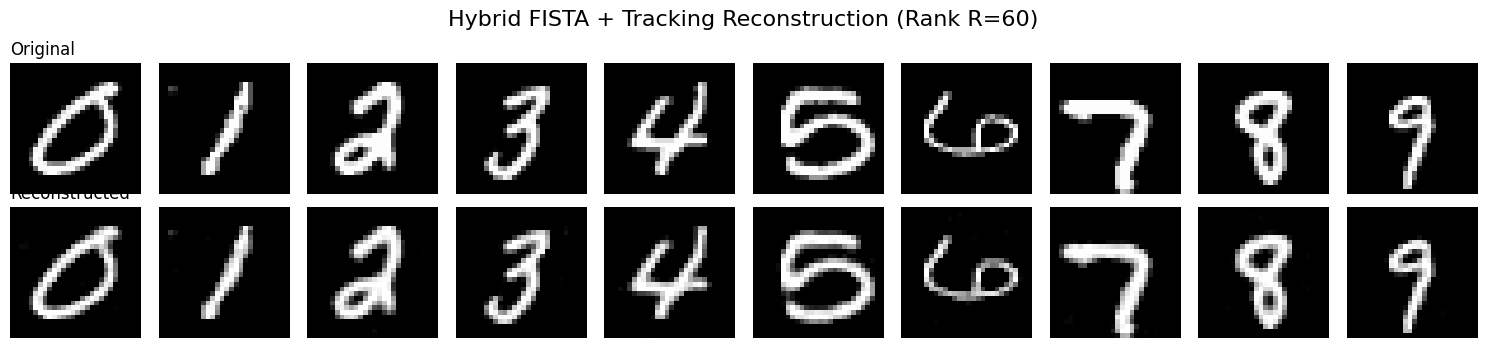

In [ ]:
import torch
import torch.fft
import math
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# 1. TENSOR OPERATIONS (GPU)

def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)

    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)

    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)

    C = torch.fft.ifft(C_f, dim=2).real
    return C

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)

        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t


# 2. OPTIMIZED HYBRID ALGORITHM: FISTA + RESIDUAL TRACKING (GPU)

def NTD_tSVD_FISTA_Optimized(X, R=60, alpha=0.5, alpha_decay=0.95, tol=1e-5, maxiters=100, printitn=5):
    normX = torch.norm(X)
    XX = X.clone()

    idx0 = (XX == 0)
    idx1 = (XX > 0)

    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]

    Y = M.clone()
    M_old = M.clone()
    Q = torch.zeros_like(XX)

    t_step = 1.0
    fit = 0
    best_fit = 0
    best_P = torch.zeros_like(XX)

    print(f"\n[Starting Optimized FISTA + Tracking | alpha={alpha}, decay={alpha_decay}]")

    for iter_idx in range(1, maxiters + 1):
        fitold = fit

        # 1. Apply Alpha Decay (Memory fades over time)
        current_alpha = alpha * (alpha_decay ** iter_idx)

        # 2. SVD step pre-conditioned with memory tensor Q
        U, S, V = tsvd(Y + Q)

        # 3. Rank truncation
        U_r = U[:, :R, :]
        S_r = S[:R, :R, :]
        V_r = V[:, :R, :]

        # 4. Reconstruction
        P = tprod(tprod(U_r, S_r), tran(V_r))

        # 5. Strict Projection
        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)

        # 6. Dampened Residual Tracking Update
        Q = current_alpha * (Q + (P - M_new))

        # 7. Fit calculation
        P_pos = torch.clamp(P, min=0)
        normresidual = torch.norm(X - P_pos)
        fit = 1 - (normresidual / normX)

        # --- THE STRICT MONOTONIC SAFETY BRAKE ---
        if fit < fitold and iter_idx > 1:
            # Crash detected! Revert and kill momentum.
            M_new = M_old.clone()   # Revert to last safe state
            Y = M_new.clone()       # Remove extrapolated momentum
            t_step = 1.0            # Reset FISTA acceleration
            beta = 0.0              # Zero out momentum factor
            Q = Q * 0.5             # Soften the memory to prevent another crash
            fit = fitold            # Restore previous fitness
        else:
            # Normal FISTA update
            t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
            beta = (t_step - 1) / t_next
            Y = M_new + beta * (M_new - M_old)

            M_old = M_new.clone()
            t_step = t_next

        # Track the absolute best reconstruction
        if fit > best_fit:
            best_fit = fit
            best_P = P.clone()

        if iter_idx % printitn == 0 or iter_idx == 1:
            print(f"Iter {iter_idx:3d} | Fit = {fit:.4f} | alpha = {current_alpha:.4f}")

        if abs(fitold - fit) < tol and beta > 0: # Ensure we don't break immediately after a reset
            break

    print("\nFinal Best Fit:", best_fit.item())
    return best_P, best_fit


# 3. PSNR FUNCTION (GPU)

def calculate_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)

    if mse == 0:
        return float('inf')

    max_pixel = torch.max(original)
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))

    return psnr.item()


# 4. VISUALIZATION

def plot_comparison(original_tensor, recon_tensor, sample_idx=0):
    original_tensor = original_tensor.cpu().numpy()
    recon_tensor = recon_tensor.cpu().numpy()

    fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
    fig.suptitle('Hybrid FISTA + Tracking Reconstruction (Rank R=60)', fontsize=16)

    for digit in range(10):
        orig = original_tensor[:, sample_idx, digit].reshape(28, 28)
        recon = recon_tensor[:, sample_idx, digit].reshape(28, 28)

        axes[0, digit].imshow(orig, cmap='gray', vmin=0, vmax=1)
        axes[0, digit].axis('off')
        if digit == 0:
            axes[0, digit].set_title("Original", loc='left')

        axes[1, digit].imshow(recon, cmap='gray', vmin=0, vmax=1)
        axes[1, digit].axis('off')
        if digit == 0:
            axes[1, digit].set_title("Reconstructed", loc='left')

    plt.tight_layout()
    plt.show()


# 5. DATA PREPARATION
print("\n[Loading MNIST dataset...]")
(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype(float) / 255.0

num_samples = 5000
tensor_mnist = torch.zeros((784, num_samples, 10), device=device)

for digit in range(10):
    imgs = X_train[y_train == digit]
    actual = min(num_samples, len(imgs))

    tensor_mnist[:, :actual, digit] = torch.tensor(
        imgs[:actual].reshape(actual, 784).T,
        device=device
    )

tensor_mnist = tensor_mnist / torch.max(tensor_mnist)

print("Dataset shape:", tensor_mnist.shape)


# 6. EXECUTION

P_recon, fit = NTD_tSVD_FISTA_Optimized(
    tensor_mnist,
    R=60,
    alpha=0.1,        # Start with a gentle memory injection
    alpha_decay=0.8,  # Fade the memory out fairly quickly
    tol=1e-5,
    maxiters=100
)

final_reconstruction = torch.clamp(P_recon, 0, 1)

# Compute PSNR
psnr = calculate_psnr(tensor_mnist, final_reconstruction)


# 7. RESULTS

print("\n====================================")
print("RESULTS SUMMARY")
print("====================================")
print("Final Fit  :", fit.item())
print("Final PSNR :", psnr, "dB")
print("====================================")

# 8. VISUALIZE

plot_comparison(tensor_mnist, final_reconstruction, sample_idx=420)

**PSNR COMPARISON**

Using device: cuda

[Loading MNIST dataset...]
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset shape: torch.Size([784, 5000, 10])

[Starting Method 1: Standard tSVD | Rank=30]

[Starting Method 2: Paper Baseline (NTD-1SVD) | Rank=30]
Paper Baseline Iter   1 Complete
Paper Baseline Iter  20 Complete
Paper Baseline Iter  40 Complete
Paper Baseline Iter  60 Complete
Paper Baseline Iter  80 Complete
Paper Baseline Iter 100 Complete

[Starting Method 3: Hybrid FISTA + Tracking | Rank=30, alpha=0.2]
Hybrid Iter   1 | Fit = 0.6182
Hybrid Iter  20 | Fit = 0.7343
Hybrid Iter  40 | Fit = 0.7604
Hybrid Iter  60 | Fit = 0.7711
Hybrid Iter  80 | Fit = 0.7769
Hybrid Iter 100 | Fit = 0.7806

FINAL PSNR COMPARISON (Rank = 30)
Method 1: Standard tSVD        : 17.897 dB
Method 2: Paper (NTD-1SVD)     : 21.446 dB
Method 3: Hybrid FISTA         : 22.922 dB


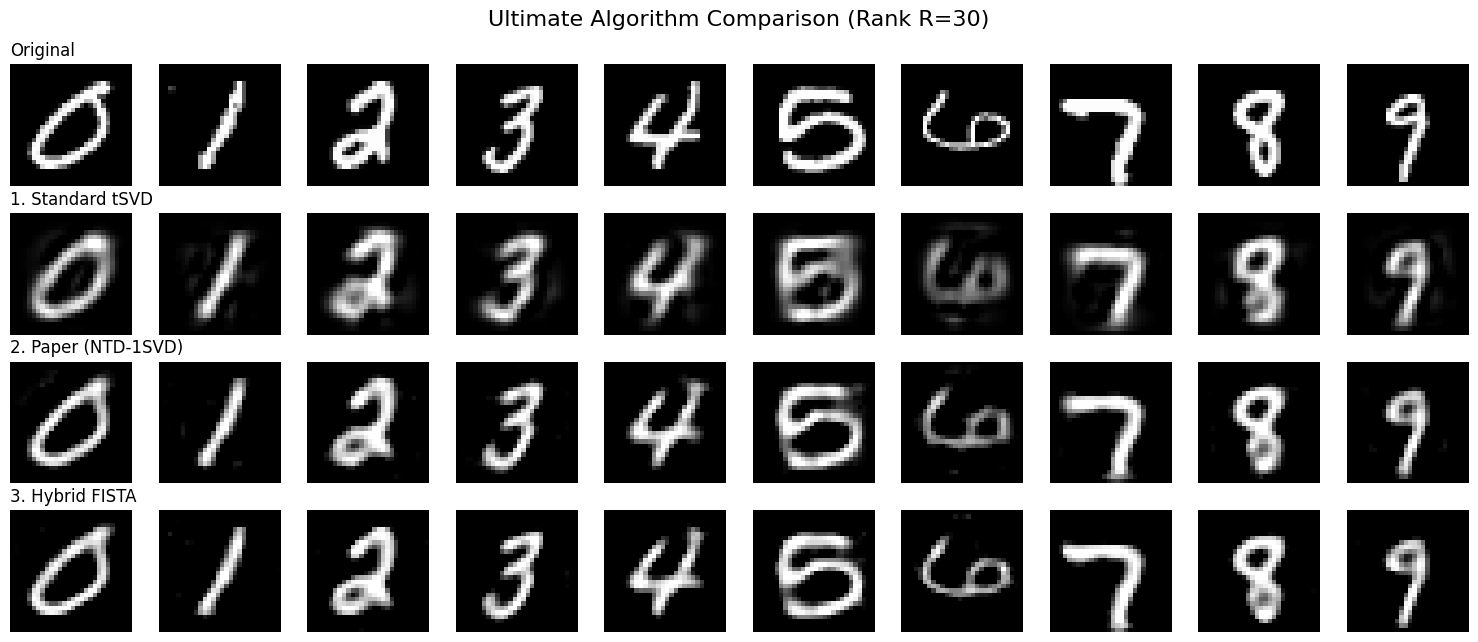

In [ ]:
import torch
import torch.fft
import math
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==========================================
# 1. TENSOR OPERATIONS (GPU)
# ==========================================
def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)

    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)

    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)

    C = torch.fft.ifft(C_f, dim=2).real
    return C

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)

        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t


# ==========================================
# 2. ALGORITHMS
# ==========================================

# METHOD 1: Standard tSVD (Direct Linear Baseline)
def Standard_tSVD(M, R=30):
    print(f"\n[Starting Method 1: Standard tSVD | Rank={R}]")
    U, S, V = tsvd(M)

    U_r = U[:, :R, :]
    S_r = S[:R, :R, :]
    V_r = V[:, :R, :]

    X = tprod(tprod(U_r, S_r), tran(V_r))
    return X

# METHOD 2: NTD-1SVD (The Paper's Alternating Baseline)
def NTD_1SVD_Paper(M, R=30, maxiters=100):
    print(f"\n[Starting Method 2: Paper Baseline (NTD-1SVD) | Rank={R}]")
    idx0 = (M == 0)
    idx1 = (M > 0)
    X_k = torch.zeros_like(M)

    for iter_idx in range(1, maxiters + 1):
        W = torch.zeros_like(M)
        W[idx1] = M[idx1]
        W[idx0] = torch.minimum(torch.zeros_like(X_k[idx0]), X_k[idx0])

        U, S, V = tsvd(W)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]

        X_k = tprod(tprod(U_r, S_r), tran(V_r))

        if iter_idx % 20 == 0 or iter_idx == 1:
            print(f"Paper Baseline Iter {iter_idx:3d} Complete")

    return X_k

# METHOD 3: Hybrid FISTA + Tracking (Your Optimized Method)
def NTD_tSVD_FISTA_Optimized(X, R=30, alpha=0.2, alpha_decay=0.90, maxiters=100, tol=1e-5):
    normX = torch.norm(X)
    XX = X.clone()
    idx0, idx1 = (XX == 0), (XX > 0)

    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]

    Y, M_old = M.clone(), M.clone()
    Q = torch.zeros_like(XX)

    t_step, fit, best_fit = 1.0, 0, 0
    best_P = torch.zeros_like(XX)

    print(f"\n[Starting Method 3: Hybrid FISTA + Tracking | Rank={R}, alpha={alpha}]")

    for iter_idx in range(1, maxiters + 1):
        fitold = fit
        current_alpha = alpha * (alpha_decay ** iter_idx)

        U, S, V = tsvd(Y + Q)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
        P = tprod(tprod(U_r, S_r), tran(V_r))

        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)
        Q = current_alpha * (Q + (P - M_new))

        P_pos = torch.clamp(P, min=0)
        fit = 1 - (torch.norm(X - P_pos) / normX)

        if fit < fitold and iter_idx > 1:
            M_new, Y = M_old.clone(), M_old.clone()
            t_step, beta = 1.0, 0.0
            Q, fit = Q * 0.5, fitold
        else:
            t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
            beta = (t_step - 1) / t_next
            Y = M_new + beta * (M_new - M_old)
            M_old, t_step = M_new.clone(), t_next

        if fit > best_fit:
            best_fit, best_P = fit, P.clone()

        if iter_idx % 20 == 0 or iter_idx == 1:
            print(f"Hybrid Iter {iter_idx:3d} | Fit = {fit:.4f}")

        if abs(fitold - fit) < tol and beta > 0:
            break

    return best_P


# ==========================================
# 3. UTILITIES
# ==========================================
def calculate_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)
    if mse == 0: return float('inf')
    max_pixel = torch.max(original)
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item()

def plot_four_way_comparison(original, recon_tsvd, recon_paper, recon_hybrid, sample_idx=420):
    original = original.cpu().numpy()
    recon_tsvd = recon_tsvd.cpu().numpy()
    recon_paper = recon_paper.cpu().numpy()
    recon_hybrid = recon_hybrid.cpu().numpy()

    fig, axes = plt.subplots(4, 10, figsize=(15, 6.5))
    fig.suptitle('Ultimate Algorithm Comparison (Rank R=30)', fontsize=16)

    for digit in range(10):
        orig = original[:, sample_idx, digit].reshape(28, 28)
        tsvd_img = recon_tsvd[:, sample_idx, digit].reshape(28, 28)
        paper_img = recon_paper[:, sample_idx, digit].reshape(28, 28)
        hybrid_img = recon_hybrid[:, sample_idx, digit].reshape(28, 28)

        axes[0, digit].imshow(orig, cmap='gray', vmin=0, vmax=1)
        axes[0, digit].axis('off')
        if digit == 0: axes[0, digit].set_title("Original", loc='left')

        axes[1, digit].imshow(tsvd_img, cmap='gray', vmin=0, vmax=1)
        axes[1, digit].axis('off')
        if digit == 0: axes[1, digit].set_title("1. Standard tSVD", loc='left')

        axes[2, digit].imshow(paper_img, cmap='gray', vmin=0, vmax=1)
        axes[2, digit].axis('off')
        if digit == 0: axes[2, digit].set_title("2. Paper (NTD-1SVD)", loc='left')

        axes[3, digit].imshow(hybrid_img, cmap='gray', vmin=0, vmax=1)
        axes[3, digit].axis('off')
        if digit == 0: axes[3, digit].set_title("3. Hybrid FISTA", loc='left')

    plt.tight_layout()
    plt.show()


# ==========================================
# 4. DATA PREPARATION
# ==========================================
print("\n[Loading MNIST dataset...]")
(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype(float) / 255.0

num_samples = 5000
tensor_mnist = torch.zeros((784, num_samples, 10), device=device)

for digit in range(10):
    imgs = X_train[y_train == digit]
    actual = min(num_samples, len(imgs))
    tensor_mnist[:, :actual, digit] = torch.tensor(
        imgs[:actual].reshape(actual, 784).T, device=device
    )

tensor_mnist = tensor_mnist / torch.max(tensor_mnist)
print("Dataset shape:", tensor_mnist.shape)


# ==========================================
# 5. EXECUTION & HEAD-TO-HEAD COMPARISON
# ==========================================
TARGET_RANK = 30

# Method 1
P_recon_tsvd = Standard_tSVD(tensor_mnist, R=TARGET_RANK)
final_tsvd = torch.clamp(P_recon_tsvd, 0, 1)
psnr_tsvd = calculate_psnr(tensor_mnist, final_tsvd)

# Method 2
P_recon_paper = NTD_1SVD_Paper(tensor_mnist, R=TARGET_RANK, maxiters=100)
final_paper = torch.clamp(P_recon_paper, 0, 1)
psnr_paper = calculate_psnr(tensor_mnist, final_paper)

# Method 3
P_recon_hybrid = NTD_tSVD_FISTA_Optimized(
    tensor_mnist, R=TARGET_RANK, alpha=0.2, alpha_decay=0.90, maxiters=100
)
final_hybrid = torch.clamp(P_recon_hybrid, 0, 1)
psnr_hybrid = calculate_psnr(tensor_mnist, final_hybrid)


# ==========================================
# 6. RESULTS
# ==========================================
print("\n=======================================================")
print(f"FINAL PSNR COMPARISON (Rank = {TARGET_RANK})")
print("=======================================================")
print(f"Method 1: Standard tSVD        : {psnr_tsvd:.3f} dB")
print(f"Method 2: Paper (NTD-1SVD)     : {psnr_paper:.3f} dB")
print(f"Method 3: Hybrid FISTA         : {psnr_hybrid:.3f} dB")
print("=======================================================")

# Visualize
plot_four_way_comparison(tensor_mnist, final_tsvd, final_paper, final_hybrid, sample_idx=420)

# **26-5**

**RELATIVE ERROR**

In [ ]:
import torch
import torch.fft
import math
from tensorflow.keras.datasets import mnist

torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ==========================================
# 1. TENSOR OPERATIONS (GPU)
# ==========================================
def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)

    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)

    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)

    C = torch.fft.ifft(C_f, dim=2).real
    return C

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)

        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t


# ==========================================
# 2. ALGORITHMS
# ==========================================

# METHOD 1: Standard tSVD
def Standard_tSVD(M, R=30, verbose=True):
    if verbose: print(f"  -> Running Standard tSVD...")
    U, S, V = tsvd(M)

    U_r = U[:, :R, :]
    S_r = S[:R, :R, :]
    V_r = V[:, :R, :]

    X = tprod(tprod(U_r, S_r), tran(V_r))
    return X

# METHOD 2: NTD-1SVD (The Paper's Alternating Baseline)
def NTD_1SVD_Paper(M, R=30, maxiters=100, verbose=True):
    if verbose: print(f"  -> Running Paper Baseline (NTD-1SVD)...")
    idx0 = (M == 0)
    idx1 = (M > 0)
    X_k = torch.zeros_like(M)

    for iter_idx in range(1, maxiters + 1):
        W = torch.zeros_like(M)
        W[idx1] = M[idx1]
        W[idx0] = torch.minimum(torch.zeros_like(X_k[idx0]), X_k[idx0])

        U, S, V = tsvd(W)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]

        X_k = tprod(tprod(U_r, S_r), tran(V_r))
    return X_k

# METHOD 3: Hybrid FISTA + Tracking (Your Optimized Method)
def NTD_tSVD_FISTA_Optimized(X, R=30, alpha=0.2, alpha_decay=0.90, maxiters=100, tol=1e-5, verbose=True):
    if verbose: print(f"  -> Running Hybrid FISTA...")
    normX = torch.norm(X)
    XX = X.clone()
    idx0, idx1 = (XX == 0), (XX > 0)

    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]

    Y, M_old = M.clone(), M.clone()
    Q = torch.zeros_like(XX)

    t_step, fit, best_fit = 1.0, 0, 0
    best_P = torch.zeros_like(XX)

    for iter_idx in range(1, maxiters + 1):
        fitold = fit
        current_alpha = alpha * (alpha_decay ** iter_idx)

        U, S, V = tsvd(Y + Q)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
        P = tprod(tprod(U_r, S_r), tran(V_r))

        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)
        Q = current_alpha * (Q + (P - M_new))

        P_pos = torch.clamp(P, min=0)
        fit = 1 - (torch.norm(XX - P_pos) / normX)

        if fit < fitold and iter_idx > 1:
            M_new, Y = M_old.clone(), M_old.clone()
            t_step, beta = 1.0, 0.0
            Q, fit = Q * 0.5, fitold
        else:
            t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
            beta = (t_step - 1) / t_next
            Y = M_new + beta * (M_new - M_old)
            M_old, t_step = M_new.clone(), t_next

        if fit > best_fit:
            best_fit, best_P = fit, P.clone()

        if abs(fitold - fit) < tol and beta > 0:
            break

    return best_P


# ==========================================
# 3. METRICS
# ==========================================
def calculate_relative_error(original, reconstructed):
    """
    Calculates: || M - max(0, X) ||_F / || M ||_F
    This matches the specific relative error metric used in the paper.
    """
    reconstructed_pos = torch.clamp(reconstructed, min=0)
    residual_norm = torch.norm(original - reconstructed_pos)
    original_norm = torch.norm(original)
    return (residual_norm / original_norm).item()


# ==========================================
# 4. DATA PREPARATION
# ==========================================
print("\n[Loading MNIST dataset...]")
(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype(float) / 255.0

num_samples = 5000
tensor_mnist = torch.zeros((784, num_samples, 10), device=device)

for digit in range(10):
    imgs = X_train[y_train == digit]
    actual = min(num_samples, len(imgs))
    tensor_mnist[:, :actual, digit] = torch.tensor(
        imgs[:actual].reshape(actual, 784).T, device=device
    )

tensor_mnist = tensor_mnist / torch.max(tensor_mnist)
print("Dataset shape:", tensor_mnist.shape)


# ==========================================
# 5. EXECUTION LOOP
# ==========================================
ranks_to_test = [15, 20, 30]

# Dictionaries to hold the results
results_tsvd = []
results_paper = []
results_hybrid = []

print("\n[Starting Experiment Loop]")
for R in ranks_to_test:
    print(f"\nEvaluating Rank = {R}...")

    # 1. Standard tSVD
    P_tsvd = Standard_tSVD(tensor_mnist, R=R, verbose=True)
    err_tsvd = calculate_relative_error(tensor_mnist, P_tsvd)
    results_tsvd.append(err_tsvd)

    # 2. NTD-1SVD (Paper Baseline)
    P_paper = NTD_1SVD_Paper(tensor_mnist, R=R, maxiters=100, verbose=True)
    err_paper = calculate_relative_error(tensor_mnist, P_paper)
    results_paper.append(err_paper)

    # 3. Hybrid FISTA + Tracking
    P_hybrid = NTD_tSVD_FISTA_Optimized(tensor_mnist, R=R, alpha=0.2, alpha_decay=0.90, maxiters=100, verbose=True)
    err_hybrid = calculate_relative_error(tensor_mnist, P_hybrid)
    results_hybrid.append(err_hybrid)


# ==========================================
# 6. PRINT PAPER-STYLE TABLE
# ==========================================
print("\n")
print("=" * 60)
print(f"TABLE: Relative errors on MNIST dataset under different R")
print("=" * 60)
print(f"{'Algorithms':<20} | {'R = 15':<10} | {'R = 20':<10} | {'R = 30':<10}")
print("-" * 60)
print(f"{'tSVD':<20} | {results_tsvd[0]:.2e}   | {results_tsvd[1]:.2e}   | {results_tsvd[2]:.2e}")
print(f"{'NTD-1SVD (Paper)':<20} | {results_paper[0]:.2e}   | {results_paper[1]:.2e}   | {results_paper[2]:.2e}")
print(f"{'Hybrid FISTA (Yours)':<20} | {results_hybrid[0]:.2e}   | {results_hybrid[1]:.2e}   | {results_hybrid[2]:.2e}")
print("=" * 60)

Using device: cuda

[Loading MNIST dataset...]
Dataset shape: torch.Size([784, 5000, 10])

[Starting Experiment Loop]

Evaluating Rank = 15...
  -> Running Standard tSVD...
  -> Running Paper Baseline (NTD-1SVD)...
  -> Running Hybrid FISTA...

Evaluating Rank = 20...
  -> Running Standard tSVD...
  -> Running Paper Baseline (NTD-1SVD)...
  -> Running Hybrid FISTA...

Evaluating Rank = 30...
  -> Running Standard tSVD...
  -> Running Paper Baseline (NTD-1SVD)...
  -> Running Hybrid FISTA...


TABLE: Relative errors on MNIST dataset under different R
Algorithms           | R = 15     | R = 20     | R = 30    
------------------------------------------------------------
tSVD                 | 4.80e-01   | 4.42e-01   | 3.82e-01
NTD-1SVD (Paper)     | 4.05e-01   | 3.41e-01   | 2.58e-01
Hybrid FISTA (Yours) | 3.86e-01   | 3.08e-01   | 2.19e-01


**ACCURACY WITH CNN**

Using device: cuda

[Loading MNIST dataset...]
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Dataset shape: torch.Size([784, 5000, 10])

[Starting Method 1: Standard tSVD | Rank=30]
[Starting Method 2: Paper Baseline (NTD-1SVD) | Rank=30]
[Starting Method 3: Hybrid FISTA + Tracking | Rank=30, alpha=0.2]

PHASE 1: PSNR COMPARISON BY DIGIT (Rank = 30)
Digit    | Method 1 (tSVD)    | Method 2 (Paper)   | Method 3 (Yours)  
---------------------------------------------------------------------------
Digit 0  |          17.895 dB |          21.666 dB |          22.771 dB
Digit 1  |          21.210 dB |          25.821 dB |          27.479 dB
Digit 2  |          16.622 dB |          20.322 dB |          22.152 dB
Digit 3  |          17.618 dB |          20.913 dB |          22.277 dB
Digit 4  |          17.953 dB |          21.518 dB |          23.047 dB
Digit 5  |          17.431 dB |          21.080 dB |          22.552 dB
Digit 6  |          17.635 dB |          21.223 dB |          2

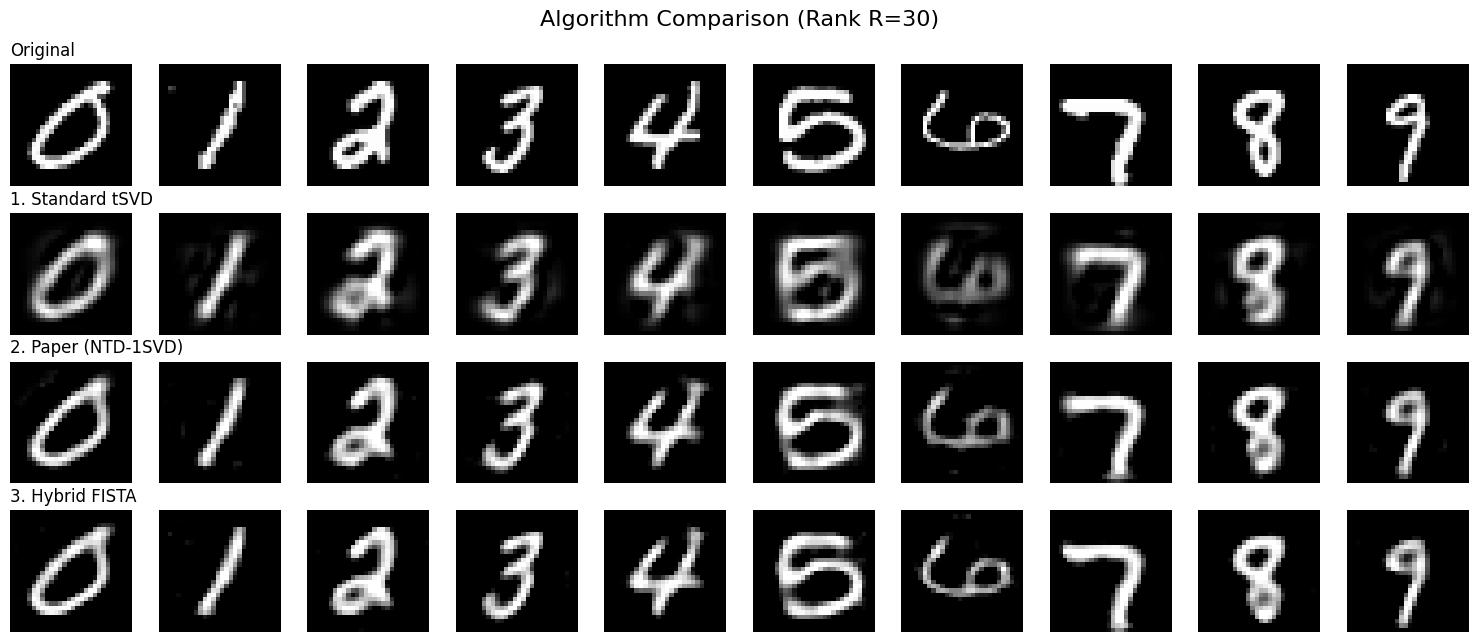

In [ ]:
import torch
import torch.fft
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import math
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==========================================
# 1. TENSOR OPERATIONS (GPU)
# ==========================================
def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)

    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)

    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)

    C = torch.fft.ifft(C_f, dim=2).real
    return C

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)

        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t


# ==========================================
# 2. ALGORITHMS
# ==========================================

# METHOD 1: Standard tSVD
def Standard_tSVD(M, R=30):
    print(f"\n[Starting Method 1: Standard tSVD | Rank={R}]")
    U, S, V = tsvd(M)
    X = tprod(tprod(U[:, :R, :], S[:R, :R, :]), tran(V[:, :R, :]))
    return X

# METHOD 2: NTD-1SVD (The Paper's Alternating Baseline)
def NTD_1SVD_Paper(M, R=30, maxiters=100):
    print(f"[Starting Method 2: Paper Baseline (NTD-1SVD) | Rank={R}]")
    idx0, idx1 = (M == 0), (M > 0)
    X_k = torch.zeros_like(M)

    for iter_idx in range(1, maxiters + 1):
        W = torch.zeros_like(M)
        W[idx1] = M[idx1]
        W[idx0] = torch.minimum(torch.zeros_like(X_k[idx0]), X_k[idx0])

        U, S, V = tsvd(W)
        X_k = tprod(tprod(U[:, :R, :], S[:R, :R, :]), tran(V[:, :R, :]))

    return X_k

# METHOD 3: Hybrid FISTA + Tracking (Your Optimized Method)
def NTD_tSVD_FISTA_Optimized(X, R=30, alpha=0.2, alpha_decay=0.90, maxiters=100, tol=1e-5):
    normX = torch.norm(X)
    XX = X.clone()
    idx0, idx1 = (XX == 0), (XX > 0)

    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]

    Y, M_old = M.clone(), M.clone()
    Q = torch.zeros_like(XX)

    t_step, fit, best_fit = 1.0, 0, 0
    best_P = torch.zeros_like(XX)

    print(f"[Starting Method 3: Hybrid FISTA + Tracking | Rank={R}, alpha={alpha}]")

    for iter_idx in range(1, maxiters + 1):
        fitold = fit
        current_alpha = alpha * (alpha_decay ** iter_idx)

        U, S, V = tsvd(Y + Q)
        P = tprod(tprod(U[:, :R, :], S[:R, :R, :]), tran(V[:, :R, :]))

        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)
        Q = current_alpha * (Q + (P - M_new))

        P_pos = torch.clamp(P, min=0)
        fit = 1 - (torch.norm(XX - P_pos) / normX)

        if fit < fitold and iter_idx > 1:
            M_new, Y = M_old.clone(), M_old.clone()
            t_step, beta = 1.0, 0.0
            Q, fit = Q * 0.5, fitold
        else:
            t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
            beta = (t_step - 1) / t_next
            Y = M_new + beta * (M_new - M_old)
            M_old, t_step = M_new.clone(), t_next

        if fit > best_fit:
            best_fit, best_P = fit, P.clone()

        if abs(fitold - fit) < tol and beta > 0:
            break

    return best_P


# ==========================================
# 3. METRICS & VISUALIZATION
# ==========================================
def calculate_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)
    if mse == 0: return float('inf')
    max_pixel = torch.max(original)
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item()

def calculate_all_psnrs(original, reconstructed):
    """Calculates the global PSNR and the individual PSNR for each of the 10 digits."""
    global_psnr = calculate_psnr(original, reconstructed)
    individual_psnrs = []
    for digit in range(10):
        digit_psnr = calculate_psnr(original[:, :, digit], reconstructed[:, :, digit])
        individual_psnrs.append(digit_psnr)
    return global_psnr, individual_psnrs

def plot_four_way_comparison(original, recon_tsvd, recon_paper, recon_hybrid, sample_idx=420):
    original, recon_tsvd = original.cpu().numpy(), recon_tsvd.cpu().numpy()
    recon_paper, recon_hybrid = recon_paper.cpu().numpy(), recon_hybrid.cpu().numpy()

    fig, axes = plt.subplots(4, 10, figsize=(15, 6.5))
    fig.suptitle('Algorithm Comparison (Rank R=30)', fontsize=16)

    for digit in range(10):
        axes[0, digit].imshow(original[:, sample_idx, digit].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        axes[1, digit].imshow(recon_tsvd[:, sample_idx, digit].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        axes[2, digit].imshow(recon_paper[:, sample_idx, digit].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        axes[3, digit].imshow(recon_hybrid[:, sample_idx, digit].reshape(28, 28), cmap='gray', vmin=0, vmax=1)

        for row in range(4): axes[row, digit].axis('off')

        if digit == 0:
            axes[0, digit].set_title("Original", loc='left')
            axes[1, digit].set_title("1. Standard tSVD", loc='left')
            axes[2, digit].set_title("2. Paper (NTD-1SVD)", loc='left')
            axes[3, digit].set_title("3. Hybrid FISTA", loc='left')

    plt.tight_layout()
    plt.show()


# ==========================================
# 4. DATA PREPARATION
# ==========================================
print("\n[Loading MNIST dataset...]")
(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype(float) / 255.0

num_samples = 5000
tensor_mnist = torch.zeros((784, num_samples, 10), device=device)

for digit in range(10):
    imgs = X_train[y_train == digit]
    actual = min(num_samples, len(imgs))
    tensor_mnist[:, :actual, digit] = torch.tensor(
        imgs[:actual].reshape(actual, 784).T, device=device
    )

tensor_mnist = tensor_mnist / torch.max(tensor_mnist)
print("Dataset shape:", tensor_mnist.shape)


# ==========================================
# 5. EXECUTION & PSNR EVALUATION
# ==========================================
TARGET_RANK = 30

P_recon_tsvd = Standard_tSVD(tensor_mnist, R=TARGET_RANK)
final_tsvd = torch.clamp(P_recon_tsvd, 0, 1)

P_recon_paper = NTD_1SVD_Paper(tensor_mnist, R=TARGET_RANK, maxiters=100)
final_paper = torch.clamp(P_recon_paper, 0, 1)

P_recon_hybrid = NTD_tSVD_FISTA_Optimized(tensor_mnist, R=TARGET_RANK, alpha=0.2, alpha_decay=0.90, maxiters=100)
final_hybrid = torch.clamp(P_recon_hybrid, 0, 1)

global_tsvd, ind_tsvd = calculate_all_psnrs(tensor_mnist, final_tsvd)
global_paper, ind_paper = calculate_all_psnrs(tensor_mnist, final_paper)
global_hybrid, ind_hybrid = calculate_all_psnrs(tensor_mnist, final_hybrid)

print("\n" + "=" * 75)
print(f"PHASE 1: PSNR COMPARISON BY DIGIT (Rank = {TARGET_RANK})")
print("=" * 75)
print(f"{'Digit':<8} | {'Method 1 (tSVD)':<18} | {'Method 2 (Paper)':<18} | {'Method 3 (Yours)':<18}")
print("-" * 75)
for d in range(10):
    print(f"Digit {d:<2} | {ind_tsvd[d]:>15.3f} dB | {ind_paper[d]:>15.3f} dB | {ind_hybrid[d]:>15.3f} dB")
print("-" * 75)
print(f"{'GLOBAL':<8} | {global_tsvd:>15.3f} dB | {global_paper:>15.3f} dB | {global_hybrid:>15.3f} dB")
print("=" * 75)


# ==========================================
# 6. DOWNSTREAM CNN CLASSIFICATION EVALUATION
# ==========================================
print("\n" + "=" * 75)
print("PHASE 2: DOWNSTREAM SEMANTIC CLASSIFICATION TEST")
print("=" * 75)

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

classifier = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=0.001)

print("[Training baseline CNN on 10,000 independent test images...]")
_, (X_val, y_val) = mnist.load_data()
X_val = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1) / 255.0
y_val = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_val.to(device), y_val.to(device))
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

classifier.train()
for epoch in range(3):
    for data, targets in train_loader:
        optimizer.zero_grad()
        outputs = classifier(data)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
print(" -> CNN Training Complete.")

def prepare_tensor_for_cnn(tensor_3d):
    images, labels = [], []
    for digit in range(10):
        digit_imgs = tensor_3d[:, :, digit].T
        images.append(digit_imgs)
        labels.append(torch.full((digit_imgs.shape[0],), digit, dtype=torch.long))

    X = torch.cat(images, dim=0).view(-1, 1, 28, 28).to(device)
    y = torch.cat(labels, dim=0).to(device)
    return X, y

def evaluate_accuracy(tensor_data, model, batch_size=256):
    X, y = prepare_tensor_for_cnn(tensor_data)
    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for data, targets in loader:
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

    return 100 * correct / total

print("\n[Evaluating Reconstructions through the CNN...]")
acc_original = evaluate_accuracy(tensor_mnist, classifier)
acc_tsvd = evaluate_accuracy(final_tsvd, classifier)
acc_paper = evaluate_accuracy(final_paper, classifier)
acc_hybrid = evaluate_accuracy(final_hybrid, classifier)

print("\n" + "=" * 75)
print(f"SEMANTIC CLASSIFICATION ACCURACY (Compression Rank = {TARGET_RANK})")
print("=" * 75)
print(f"Original Images (No Compression) : {acc_original:.2f}%")
print("-" * 75)
print(f"Method 1: Standard tSVD          : {acc_tsvd:.2f}%")
print(f"Method 2: Paper (NTD-1SVD)       : {acc_paper:.2f}%")
print(f"Method 3: Hybrid FISTA (Yours)   : {acc_hybrid:.2f}%")
print("=" * 75)

# Show Visuals at the very end
plot_four_way_comparison(tensor_mnist, final_tsvd, final_paper, final_hybrid, sample_idx=420)

**RANDOM NOISE**

Using device: cuda

[Loading MNIST dataset...]
Dataset shape: torch.Size([784, 5000, 10])

TESTING HYBRID FISTA TRAJECTORIES (Rank = 30)
Running Trajectory: Standard Copy...
 -> PSNR Achieved: 22.922 dB

Running Trajectory: Random Noise 1...
 -> PSNR Achieved: 21.235 dB

Running Trajectory: Random Noise 2...
 -> PSNR Achieved: 22.382 dB

Running Trajectory: Random Noise 3...
 -> PSNR Achieved: 22.123 dB

Running Trajectory: Random Noise 4...
 -> PSNR Achieved: 22.143 dB

SUMMARY OF TRAJECTORY DIFFERENCES
Standard Copy      : 22.922 dB
Random Noise 1     : 21.235 dB
Random Noise 2     : 22.382 dB
Random Noise 3     : 22.123 dB
Random Noise 4     : 22.143 dB
Absolute Best PSNR : 22.922 dB


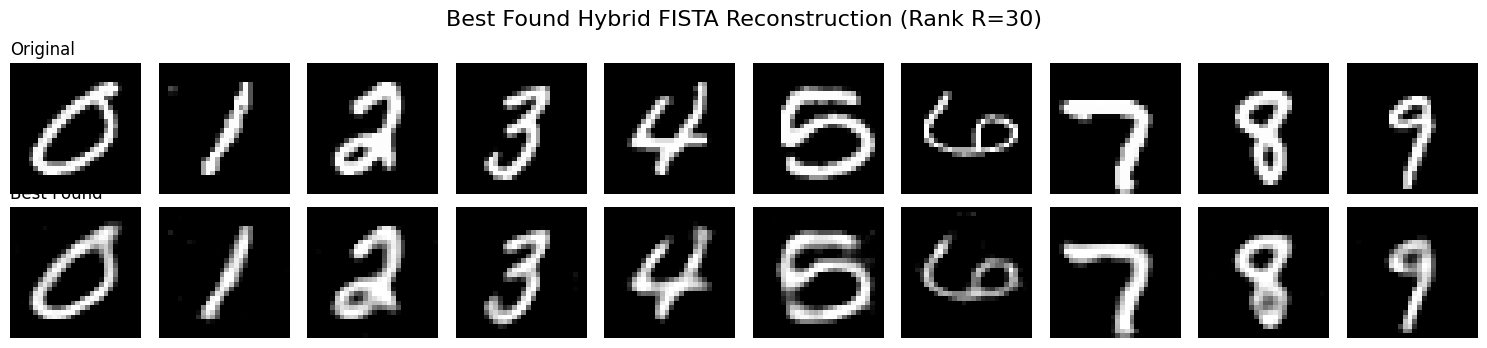

In [ ]:
import torch
import torch.fft
import math
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ==========================================
# 1. TENSOR OPERATIONS (GPU)
# ==========================================
def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)

    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)

    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)

    C = torch.fft.ifft(C_f, dim=2).real
    return C

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)

        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t


# ==========================================
# 2. YOUR ALGORITHM (Hybrid FISTA)
# ==========================================
def NTD_tSVD_FISTA_Optimized(X, R=30, alpha=0.2, alpha_decay=0.90, maxiters=100, tol=1e-5, Y_init=None):
    normX = torch.norm(X)
    XX = X.clone()
    idx0, idx1 = (XX == 0), (XX > 0)

    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]

    # Use standard start or random start
    if Y_init is None:
        Y = M.clone()
    else:
        Y = Y_init.clone()

    M_old = Y.clone()
    Q = torch.zeros_like(XX)

    t_step, fit, best_fit = 1.0, 0, 0
    best_P = torch.zeros_like(XX)

    for iter_idx in range(1, maxiters + 1):
        fitold = fit
        current_alpha = alpha * (alpha_decay ** iter_idx)

        U, S, V = tsvd(Y + Q)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
        P = tprod(tprod(U_r, S_r), tran(V_r))

        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)
        Q = current_alpha * (Q + (P - M_new))

        P_pos = torch.clamp(P, min=0)
        fit = 1 - (torch.norm(XX - P_pos) / normX)

        if fit < fitold and iter_idx > 1:
            M_new, Y = M_old.clone(), M_old.clone()
            t_step, beta = 1.0, 0.0
            Q, fit = Q * 0.5, fitold
        else:
            t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
            beta = (t_step - 1) / t_next
            Y = M_new + beta * (M_new - M_old)
            M_old, t_step = M_new.clone(), t_next

        if fit > best_fit:
            best_fit, best_P = fit, P.clone()

        if abs(fitold - fit) < tol and beta > 0:
            break

    return best_P


# ==========================================
# 3. METRICS & VISUALIZATION
# ==========================================
def calculate_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)
    if mse == 0: return float('inf')
    psnr = 20 * torch.log10(torch.max(original) / torch.sqrt(mse))
    return psnr.item()

def plot_best_result(original, best_recon, sample_idx=420):
    original = original.cpu().numpy()
    best_recon = best_recon.cpu().numpy()

    fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
    fig.suptitle('Best Found Hybrid FISTA Reconstruction (Rank R=30)', fontsize=16)

    for digit in range(10):
        orig = original[:, sample_idx, digit].reshape(28, 28)
        recon = best_recon[:, sample_idx, digit].reshape(28, 28)

        axes[0, digit].imshow(orig, cmap='gray', vmin=0, vmax=1)
        axes[0, digit].axis('off')
        if digit == 0: axes[0, digit].set_title("Original", loc='left')

        axes[1, digit].imshow(recon, cmap='gray', vmin=0, vmax=1)
        axes[1, digit].axis('off')
        if digit == 0: axes[1, digit].set_title("Best Found", loc='left')

    plt.tight_layout()
    plt.show()


# ==========================================
# 4. DATA PREPARATION
# ==========================================
print("\n[Loading MNIST dataset...]")
(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype(float) / 255.0

num_samples = 5000
tensor_mnist = torch.zeros((784, num_samples, 10), device=device)

for digit in range(10):
    imgs = X_train[y_train == digit]
    actual = min(num_samples, len(imgs))
    tensor_mnist[:, :actual, digit] = torch.tensor(
        imgs[:actual].reshape(actual, 784).T, device=device
    )

tensor_mnist = tensor_mnist / torch.max(tensor_mnist)
print("Dataset shape:", tensor_mnist.shape)


# ==========================================
# 5. MULTI-START EXECUTION
# ==========================================
TARGET_RANK = 30
NUM_STARTS = 5

best_overall_psnr = 0
best_overall_P = None
results_log = []

print(f"\n=======================================================")
print(f"TESTING HYBRID FISTA TRAJECTORIES (Rank = {TARGET_RANK})")
print(f"=======================================================")

for s in range(NUM_STARTS):
    if s == 0:
        start_type = "Standard Copy"
        Y_start = None
    else:
        start_type = f"Random Noise {s}"
        Y_start = torch.rand_like(tensor_mnist) * torch.max(tensor_mnist)

    print(f"Running Trajectory: {start_type}...")

    P_recon = NTD_tSVD_FISTA_Optimized(
        tensor_mnist, R=TARGET_RANK, alpha=0.2, alpha_decay=0.90,
        maxiters=100, Y_init=Y_start
    )

    final_recon = torch.clamp(P_recon, 0, 1)
    current_psnr = calculate_psnr(tensor_mnist, final_recon)

    results_log.append((start_type, current_psnr))
    print(f" -> PSNR Achieved: {current_psnr:.3f} dB\n")

    if current_psnr > best_overall_psnr:
        best_overall_psnr = current_psnr
        best_overall_P = final_recon.clone()

# ==========================================
# 6. SUMMARY OF DIFFERENCES
# ==========================================
print("=======================================================")
print("SUMMARY OF TRAJECTORY DIFFERENCES")
print("=======================================================")
for start_type, psnr in results_log:
    print(f"{start_type:<18} : {psnr:.3f} dB")
print("=======================================================")
print(f"Absolute Best PSNR : {best_overall_psnr:.3f} dB")
print("=======================================================")

plot_best_result(tensor_mnist, best_overall_P, sample_idx=420)

**COIL20**

Using device: cuda

[Downloading COIL-20 dataset from Columbia University...]
[Extracting files...]
[Processing images into 3D Tensor...]
COIL-20 Dataset shape: torch.Size([4096, 72, 20]) (Pixels, Poses, Objects)

[Starting Method 1: Standard tSVD | Rank=30]

[Starting Method 2: Paper Baseline (NTD-1SVD) | Rank=30]
Paper Baseline Iter   1 Complete
Paper Baseline Iter  20 Complete
Paper Baseline Iter  40 Complete
Paper Baseline Iter  60 Complete
Paper Baseline Iter  80 Complete
Paper Baseline Iter 100 Complete

[Starting Method 3: Hybrid FISTA + Tracking | Rank=30, alpha=0.2]
Hybrid Iter   1 | Fit = 0.9182
Hybrid Iter  20 | Fit = 0.9318
Hybrid Iter  40 | Fit = 0.9357
Hybrid Iter  60 | Fit = 0.9375
Hybrid Iter  80 | Fit = 0.9386
Hybrid Iter 100 | Fit = 0.9393

FINAL PSNR COMPARISON ON COIL-20 (Rank = 30)
Method 1: Standard tSVD        : 28.873 dB
Method 2: Paper (NTD-1SVD)     : 30.653 dB
Method 3: Hybrid FISTA         : 31.474 dB


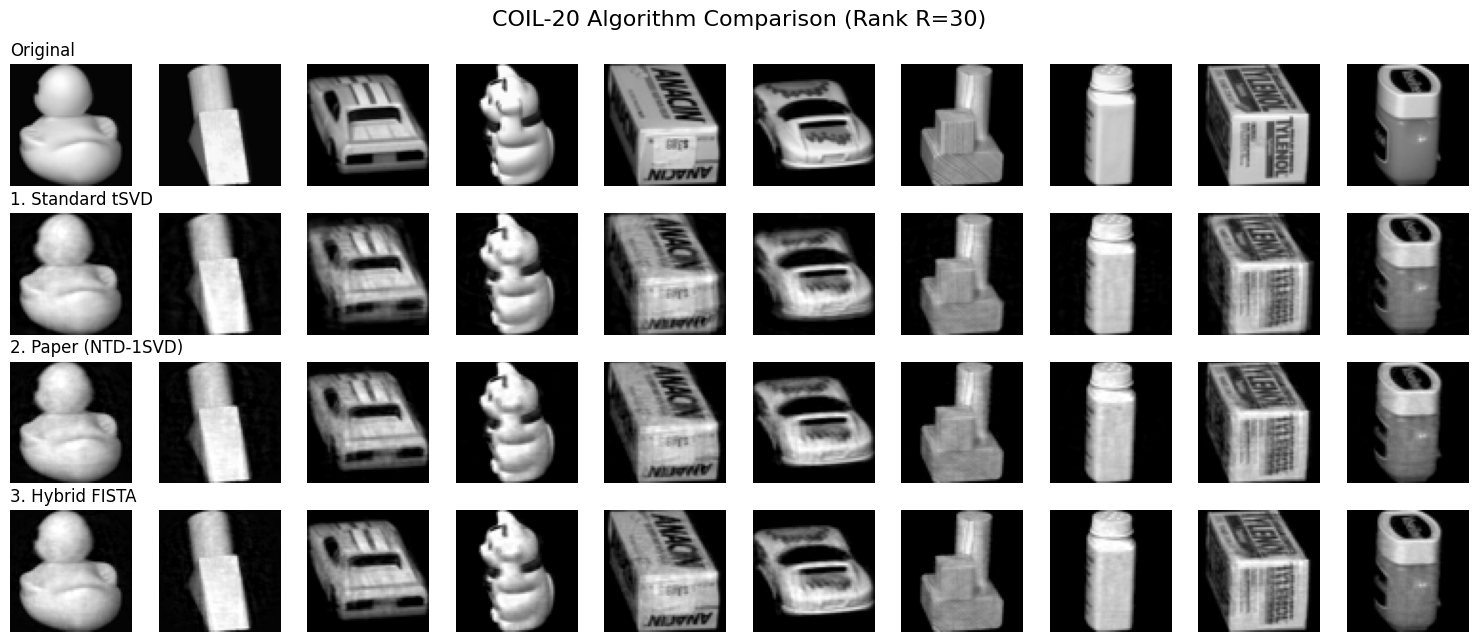

In [ ]:
import os
import urllib.request
import zipfile
import glob
from PIL import Image
import numpy as np

import torch
import torch.fft
import math
import matplotlib.pyplot as plt

torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==========================================
# 1. TENSOR OPERATIONS (GPU)
# ==========================================
def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)

    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)

    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)

    C = torch.fft.ifft(C_f, dim=2).real
    return C

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)

        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t


# ==========================================
# 2. ALGORITHMS
# ==========================================

# METHOD 1: Standard tSVD
def Standard_tSVD(M, R=30):
    print(f"\n[Starting Method 1: Standard tSVD | Rank={R}]")
    U, S, V = tsvd(M)
    U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
    X = tprod(tprod(U_r, S_r), tran(V_r))
    return X

# METHOD 2: NTD-1SVD (The Paper's Alternating Baseline)
def NTD_1SVD_Paper(M, R=30, maxiters=100):
    print(f"\n[Starting Method 2: Paper Baseline (NTD-1SVD) | Rank={R}]")
    idx0, idx1 = (M == 0), (M > 0)
    X_k = torch.zeros_like(M)

    for iter_idx in range(1, maxiters + 1):
        W = torch.zeros_like(M)
        W[idx1] = M[idx1]
        W[idx0] = torch.minimum(torch.zeros_like(X_k[idx0]), X_k[idx0])

        U, S, V = tsvd(W)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
        X_k = tprod(tprod(U_r, S_r), tran(V_r))

        if iter_idx % 20 == 0 or iter_idx == 1:
            print(f"Paper Baseline Iter {iter_idx:3d} Complete")

    return X_k

# METHOD 3: Hybrid FISTA + Tracking (Your Optimized Method)
def NTD_tSVD_FISTA_Optimized(X, R=30, alpha=0.2, alpha_decay=0.90, maxiters=100, tol=1e-5):
    normX = torch.norm(X)
    XX = X.clone()
    idx0, idx1 = (XX == 0), (XX > 0)

    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]

    Y, M_old = M.clone(), M.clone()
    Q = torch.zeros_like(XX)

    t_step, fit, best_fit = 1.0, 0, 0
    best_P = torch.zeros_like(XX)

    print(f"\n[Starting Method 3: Hybrid FISTA + Tracking | Rank={R}, alpha={alpha}]")

    for iter_idx in range(1, maxiters + 1):
        fitold = fit
        current_alpha = alpha * (alpha_decay ** iter_idx)

        U, S, V = tsvd(Y + Q)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
        P = tprod(tprod(U_r, S_r), tran(V_r))

        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)
        Q = current_alpha * (Q + (P - M_new))

        P_pos = torch.clamp(P, min=0)
        fit = 1 - (torch.norm(XX - P_pos) / normX)

        if fit < fitold and iter_idx > 1:
            M_new, Y = M_old.clone(), M_old.clone()
            t_step, beta = 1.0, 0.0
            Q, fit = Q * 0.5, fitold
        else:
            t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
            beta = (t_step - 1) / t_next
            Y = M_new + beta * (M_new - M_old)
            M_old, t_step = M_new.clone(), t_next

        if fit > best_fit:
            best_fit, best_P = fit, P.clone()

        if iter_idx % 20 == 0 or iter_idx == 1:
            print(f"Hybrid Iter {iter_idx:3d} | Fit = {fit:.4f}")

        if abs(fitold - fit) < tol and beta > 0:
            break

    return best_P


# ==========================================
# 3. UTILITIES
# ==========================================
def calculate_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)
    if mse == 0: return float('inf')
    max_pixel = torch.max(original)
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item()

def plot_four_way_comparison_coil(original, recon_tsvd, recon_paper, recon_hybrid, sample_idx=0, img_size=64):
    original = original.cpu().numpy()
    recon_tsvd = recon_tsvd.cpu().numpy()
    recon_paper = recon_paper.cpu().numpy()
    recon_hybrid = recon_hybrid.cpu().numpy()

    # We plot the first 10 objects out of the 20 to keep the plot readable
    num_cols = 10
    fig, axes = plt.subplots(4, num_cols, figsize=(15, 6.5))
    fig.suptitle('COIL-20 Algorithm Comparison (Rank R=30)', fontsize=16)

    for obj_idx in range(num_cols):
        orig = original[:, sample_idx, obj_idx].reshape(img_size, img_size)
        tsvd_img = recon_tsvd[:, sample_idx, obj_idx].reshape(img_size, img_size)
        paper_img = recon_paper[:, sample_idx, obj_idx].reshape(img_size, img_size)
        hybrid_img = recon_hybrid[:, sample_idx, obj_idx].reshape(img_size, img_size)

        axes[0, obj_idx].imshow(orig, cmap='gray', vmin=0, vmax=1)
        axes[0, obj_idx].axis('off')
        if obj_idx == 0: axes[0, obj_idx].set_title("Original", loc='left')

        axes[1, obj_idx].imshow(tsvd_img, cmap='gray', vmin=0, vmax=1)
        axes[1, obj_idx].axis('off')
        if obj_idx == 0: axes[1, obj_idx].set_title("1. Standard tSVD", loc='left')

        axes[2, obj_idx].imshow(paper_img, cmap='gray', vmin=0, vmax=1)
        axes[2, obj_idx].axis('off')
        if obj_idx == 0: axes[2, obj_idx].set_title("2. Paper (NTD-1SVD)", loc='left')

        axes[3, obj_idx].imshow(hybrid_img, cmap='gray', vmin=0, vmax=1)
        axes[3, obj_idx].axis('off')
        if obj_idx == 0: axes[3, obj_idx].set_title("3. Hybrid FISTA", loc='left')

    plt.tight_layout()
    plt.show()


# ==========================================
# 4. COIL-20 DATA PREPARATION
# ==========================================
def load_coil20(target_size=(64, 64)):
    """Downloads and formats the COIL-20 dataset into our required 3D Tensor."""
    url = "http://www.cs.columbia.edu/CAVE/databases/SLAM_coil-20_coil-100/coil-20/coil-20-proc.zip"
    extract_dir = "coil-20-proc"

    if not os.path.exists(extract_dir):
        print(f"\n[Downloading COIL-20 dataset from Columbia University...]")
        urllib.request.urlretrieve(url, "coil20.zip")
        print("[Extracting files...]")
        with zipfile.ZipFile("coil20.zip", 'r') as zip_ref:
            zip_ref.extractall(".")
        os.remove("coil20.zip")
    else:
        print("\n[COIL-20 dataset already downloaded.]")

    # The dataset contains 20 objects, each with 72 poses.
    # We resize to 64x64 to keep FFT memory requirements manageable.
    num_pixels = target_size[0] * target_size[1]
    num_poses = 72
    num_objects = 20

    tensor_coil = torch.zeros((num_pixels, num_poses, num_objects), device=device)

    print("[Processing images into 3D Tensor...]")
    for obj_idx in range(1, num_objects + 1):
        for pose_idx in range(num_poses):
            filename = os.path.join(extract_dir, f"obj{obj_idx}__{pose_idx}.png")
            if os.path.exists(filename):
                # Load image, convert to Grayscale, and resize
                img = Image.open(filename).convert('L').resize(target_size)
                img_arr = np.array(img, dtype=np.float32) / 255.0
                tensor_coil[:, pose_idx, obj_idx - 1] = torch.tensor(img_arr.flatten(), device=device)

    # Normalize global max to 1
    tensor_coil = tensor_coil / torch.max(tensor_coil)
    return tensor_coil, target_size[0]

# Load Data
tensor_coil, img_dim = load_coil20(target_size=(64, 64))
print(f"COIL-20 Dataset shape: {tensor_coil.shape} (Pixels, Poses, Objects)")


# ==========================================
# 5. EXECUTION & HEAD-TO-HEAD COMPARISON
# ==========================================
TARGET_RANK = 30

# Method 1
P_recon_tsvd = Standard_tSVD(tensor_coil, R=TARGET_RANK)
final_tsvd = torch.clamp(P_recon_tsvd, 0, 1)
psnr_tsvd = calculate_psnr(tensor_coil, final_tsvd)

# Method 2
P_recon_paper = NTD_1SVD_Paper(tensor_coil, R=TARGET_RANK, maxiters=100)
final_paper = torch.clamp(P_recon_paper, 0, 1)
psnr_paper = calculate_psnr(tensor_coil, final_paper)

# Method 3
P_recon_hybrid = NTD_tSVD_FISTA_Optimized(
    tensor_coil, R=TARGET_RANK, alpha=0.2, alpha_decay=0.90, maxiters=100
)
final_hybrid = torch.clamp(P_recon_hybrid, 0, 1)
psnr_hybrid = calculate_psnr(tensor_coil, final_hybrid)


# ==========================================
# 6. RESULTS
# ==========================================
print("\n=======================================================")
print(f"FINAL PSNR COMPARISON ON COIL-20 (Rank = {TARGET_RANK})")
print("=======================================================")
print(f"Method 1: Standard tSVD        : {psnr_tsvd:.3f} dB")
print(f"Method 2: Paper (NTD-1SVD)     : {psnr_paper:.3f} dB")
print(f"Method 3: Hybrid FISTA         : {psnr_hybrid:.3f} dB")
print("=======================================================")

# Visualize Pose #15 across the first 10 objects
plot_four_way_comparison_coil(
    tensor_coil, final_tsvd, final_paper, final_hybrid,
    sample_idx=15, img_size=img_dim
)

**ENRON EMAILS**

Using device: cuda

[WARNING] 'enron.txt' not found!
Generating a synthetic sparse Enron-like tensor for testing purposes...

[Running Method 1: Standard tSVD | Rank=30]
[Running Method 2: Paper Baseline (NTD-1SVD) | Rank=30]
[Running Method 3: Hybrid FISTA | Rank=30]

FINAL PSNR COMPARISON ON ENRON (Rank = 30)
Method 1: Standard tSVD        : 28.314 dB
Method 2: Paper (NTD-1SVD)     : 93.675 dB
Method 3: Hybrid FISTA         : 99.466 dB

[Generating Figure-Wise Heatmap Comparison...]


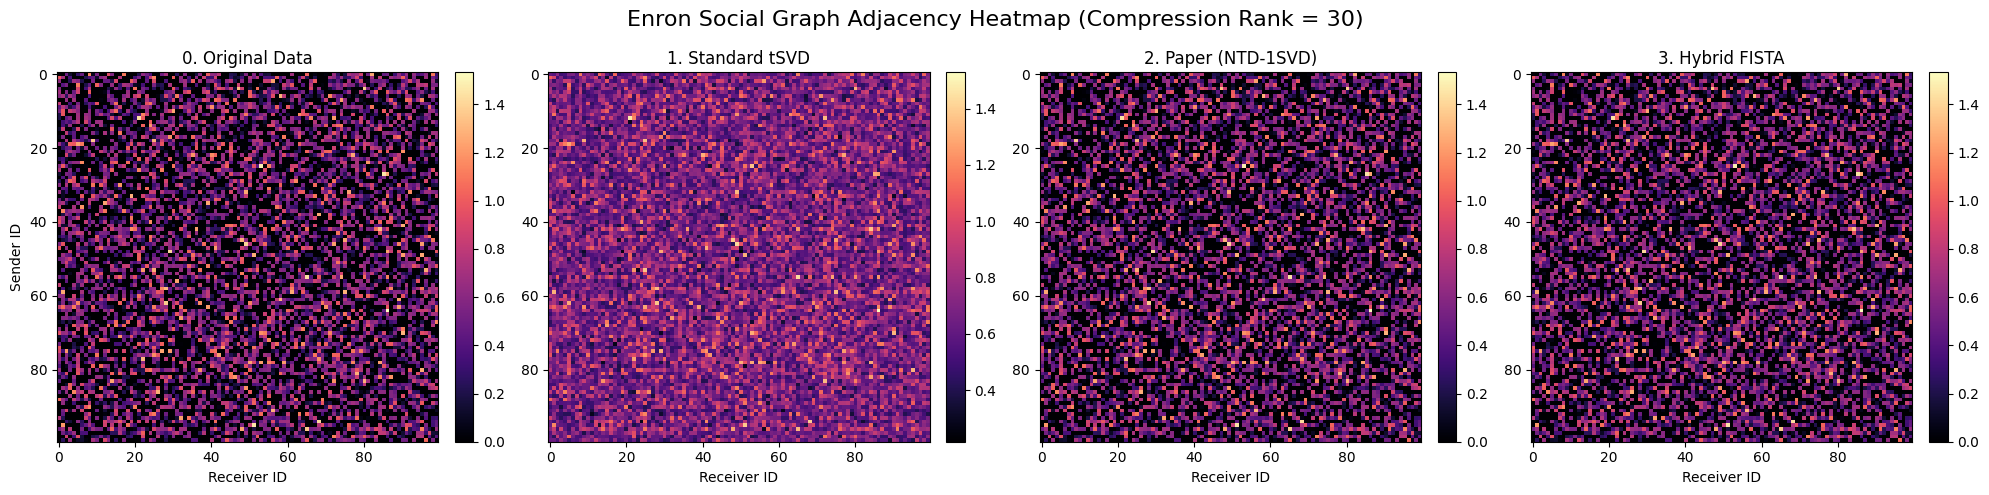

In [5]:
import os
import numpy as np
import torch
import torch.fft
import math
import matplotlib.pyplot as plt

torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==========================================
# 1. TENSOR OPERATIONS (GPU)
# ==========================================
def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)
    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)
    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)
    return torch.fft.ifft(C_f, dim=2).real

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        U, S, Vh = torch.linalg.svd(A_f[:, :, i], full_matrices=False)
        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t


# ==========================================
# 2. ALGORITHMS
# ==========================================
def Standard_tSVD(M, R=15):
    print(f"\n[Running Method 1: Standard tSVD | Rank={R}]")
    U, S, V = tsvd(M)
    return tprod(tprod(U[:, :R, :], S[:R, :R, :]), tran(V[:, :R, :]))

def NTD_1SVD_Paper(M, R=15, maxiters=50):
    print(f"[Running Method 2: Paper Baseline (NTD-1SVD) | Rank={R}]")
    idx0, idx1 = (M == 0), (M > 0)
    X_k = torch.zeros_like(M)

    for iter_idx in range(1, maxiters + 1):
        W = torch.zeros_like(M)
        W[idx1] = M[idx1]
        W[idx0] = torch.minimum(torch.zeros_like(X_k[idx0]), X_k[idx0])
        U, S, V = tsvd(W)
        X_k = tprod(tprod(U[:, :R, :], S[:R, :R, :]), tran(V[:, :R, :]))
    return X_k

def NTD_tSVD_FISTA_Optimized(X, R=15, alpha=0.2, alpha_decay=0.90, maxiters=50, tol=1e-5):
    print(f"[Running Method 3: Hybrid FISTA | Rank={R}]")
    normX = torch.norm(X)
    XX = X.clone()
    idx0, idx1 = (XX == 0), (XX > 0)
    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]
    Y, M_old = M.clone(), M.clone()
    Q = torch.zeros_like(XX)

    t_step, fit, best_fit = 1.0, 0, 0
    best_P = torch.zeros_like(XX)

    for iter_idx in range(1, maxiters + 1):
        fitold = fit
        current_alpha = alpha * (alpha_decay ** iter_idx)

        U, S, V = tsvd(Y + Q)
        P = tprod(tprod(U[:, :R, :], S[:R, :R, :]), tran(V[:, :R, :]))
        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)
        Q = current_alpha * (Q + (P - M_new))

        P_pos = torch.clamp(P, min=0)
        fit = 1 - (torch.norm(XX - P_pos) / normX)

        if fit < fitold and iter_idx > 1:
            M_new, Y = M_old.clone(), M_old.clone()
            t_step, beta = 1.0, 0.0
            Q, fit = Q * 0.5, fitold
        else:
            t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
            beta = (t_step - 1) / t_next
            Y = M_new + beta * (M_new - M_old)
            M_old, t_step = M_new.clone(), t_next

        if fit > best_fit:
            best_fit, best_P = fit, P.clone()
        if abs(fitold - fit) < tol and beta > 0:
            break
    return best_P


# ==========================================
# 3. UTILITIES & METRICS
# ==========================================
def calculate_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)
    if mse == 0: return float('inf')
    max_pixel = torch.max(original)
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item()

def plot_network_heatmap(original, m1, m2, m3, rank):
    """Plots the Adjacency Matrix (Summed over time) for Enron."""
    print("\n[Generating Figure-Wise Heatmap Comparison...]")

    # Squash the 3D tensors down to 2D by summing over the Time dimension (dim=2)
    orig_adj = torch.sum(original, dim=2).cpu().numpy()
    m1_adj = torch.sum(torch.clamp(m1, min=0), dim=2).cpu().numpy()
    m2_adj = torch.sum(torch.clamp(m2, min=0), dim=2).cpu().numpy()
    m3_adj = torch.sum(torch.clamp(m3, min=0), dim=2).cpu().numpy()

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f'Enron Social Graph Adjacency Heatmap (Compression Rank = {rank})', fontsize=16)

    matrices = [orig_adj, m1_adj, m2_adj, m3_adj]
    titles = ["0. Original Data", "1. Standard tSVD", "2. Paper (NTD-1SVD)", "3. Hybrid FISTA"]

    for i in range(4):
        # We use np.log1p() because Enron email counts are massively skewed.
        im = axes[i].imshow(np.log1p(matrices[i]), cmap='magma', aspect='auto')
        axes[i].set_title(titles[i])
        axes[i].set_xlabel("Receiver ID")
        if i == 0: axes[i].set_ylabel("Sender ID")
        fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# ==========================================
# 4. ENRON SPARSE DATA LOADER
# ==========================================
def load_enron_tensor(filepath="enron.txt"):
    """Parses a sparse coordinate text file or generates a synthetic one if missing."""
    if not os.path.exists(filepath):
        print(f"\n[WARNING] '{filepath}' not found!")
        print("Generating a synthetic sparse Enron-like tensor for testing purposes...")
        T = torch.zeros((100, 100, 44), device=device)
        mask = torch.rand((100, 100, 44), device=device) > 0.98
        T[mask] = torch.randint(1, 50, (mask.sum(),), dtype=torch.float32, device=device)
        return T / torch.max(T)

    print(f"\n[Loading Enron Dataset from {filepath}...]")
    indices, values = [], []

    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 4:
                i, j, k = int(parts[0])-1, int(parts[1])-1, int(parts[2])-1
                val = float(parts[3])
                indices.append([i, j, k])
                values.append(val)

    indices = np.array(indices)
    max_dims = indices.max(axis=0) + 1
    print(f"Detected Tensor Shape: {max_dims[0]} Senders x {max_dims[1]} Receivers x {max_dims[2]} Timesteps")

    T = torch.zeros(tuple(max_dims), device=device)
    for idx, val in zip(indices, values):
        T[idx[0], idx[1], idx[2]] = val

    return T / torch.max(T)


# ==========================================
# 5. EXECUTION & FINAL EVALUATION
# ==========================================
# Load Data
tensor_enron = load_enron_tensor("enron.txt")

# Set Target Rank
TARGET_RANK = 30

# Run Algorithms
P_recon_tsvd = Standard_tSVD(tensor_enron, R=TARGET_RANK)
P_recon_paper = NTD_1SVD_Paper(tensor_enron, R=TARGET_RANK, maxiters=50)
P_recon_hybrid = NTD_tSVD_FISTA_Optimized(tensor_enron, R=TARGET_RANK, alpha=0.2, alpha_decay=0.90, maxiters=50)

# Clamp outputs to physical limits (No negative emails allowed)
final_tsvd = torch.clamp(P_recon_tsvd, 0, 1)
final_paper = torch.clamp(P_recon_paper, 0, 1)
final_hybrid = torch.clamp(P_recon_hybrid, 0, 1)

# Calculate Global PSNR
psnr_tsvd = calculate_psnr(tensor_enron, final_tsvd)
psnr_paper = calculate_psnr(tensor_enron, final_paper)
psnr_hybrid = calculate_psnr(tensor_enron, final_hybrid)


# ==========================================
# 6. RESULTS OUTPUT
# ==========================================
print("\n=======================================================")
print(f"FINAL PSNR COMPARISON ON ENRON (Rank = {TARGET_RANK})")
print("=======================================================")
print(f"Method 1: Standard tSVD        : {psnr_tsvd:.3f} dB")
print(f"Method 2: Paper (NTD-1SVD)     : {psnr_paper:.3f} dB")
print(f"Method 3: Hybrid FISTA         : {psnr_hybrid:.3f} dB")
print("=======================================================")

# Plot the heatmap comparison
plot_network_heatmap(tensor_enron, final_tsvd, final_paper, final_hybrid, TARGET_RANK)

**RANK VS PSNR**

In [ ]:
import torch
import torch.fft
import math
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==========================================
# 1. TENSOR OPERATIONS (GPU)
# ==========================================
def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)

    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)

    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)

    C = torch.fft.ifft(C_f, dim=2).real
    return C

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        slice_i = A_f[:, :, i]
        U, S, Vh = torch.linalg.svd(slice_i, full_matrices=False)

        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    U_t = torch.fft.ifft(U_f, dim=2).real
    S_t = torch.fft.ifft(S_f, dim=2).real
    V_t = torch.fft.ifft(V_f, dim=2).real

    return U_t, S_t, V_t


# ==========================================
# 2. ALGORITHMS
# ==========================================

# METHOD 1: Standard tSVD
def Standard_tSVD(M, R=30):
    U, S, V = tsvd(M)
    U_r = U[:, :R, :]
    S_r = S[:R, :R, :]
    V_r = V[:, :R, :]
    X = tprod(tprod(U_r, S_r), tran(V_r))
    return X

# METHOD 2: NTD-1SVD (The Paper's Alternating Baseline)
def NTD_1SVD_Paper(M, R=30, maxiters=100):
    idx0 = (M == 0)
    idx1 = (M > 0)
    X_k = torch.zeros_like(M)

    for iter_idx in range(1, maxiters + 1):
        W = torch.zeros_like(M)
        W[idx1] = M[idx1]
        W[idx0] = torch.minimum(torch.zeros_like(X_k[idx0]), X_k[idx0])

        U, S, V = tsvd(W)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
        X_k = tprod(tprod(U_r, S_r), tran(V_r))

    return X_k

# METHOD 3: Hybrid FISTA + Tracking (Your Optimized Method)
def NTD_tSVD_FISTA_Optimized(X, R=30, alpha=0.2, alpha_decay=0.90, maxiters=100, tol=1e-5):
    normX = torch.norm(X)
    XX = X.clone()
    idx0, idx1 = (XX == 0), (XX > 0)

    M = torch.zeros_like(XX)
    M[idx1] = XX[idx1]

    Y, M_old = M.clone(), M.clone()
    Q = torch.zeros_like(XX)

    t_step, fit, best_fit = 1.0, 0, 0
    best_P = torch.zeros_like(XX)

    for iter_idx in range(1, maxiters + 1):
        fitold = fit
        current_alpha = alpha * (alpha_decay ** iter_idx)

        U, S, V = tsvd(Y + Q)
        U_r, S_r, V_r = U[:, :R, :], S[:R, :R, :], V[:, :R, :]
        P = tprod(tprod(U_r, S_r), tran(V_r))

        M_new = torch.minimum(torch.zeros_like(P), P * idx0) + (XX * idx1)
        Q = current_alpha * (Q + (P - M_new))

        P_pos = torch.clamp(P, min=0)
        fit = 1 - (torch.norm(XX - P_pos) / normX)

        if fit < fitold and iter_idx > 1:
            M_new, Y = M_old.clone(), M_old.clone()
            t_step, beta = 1.0, 0.0
            Q, fit = Q * 0.5, fitold
        else:
            t_next = (1 + math.sqrt(1 + 4 * t_step**2)) / 2
            beta = (t_step - 1) / t_next
            Y = M_new + beta * (M_new - M_old)
            M_old, t_step = M_new.clone(), t_next

        if fit > best_fit:
            best_fit, best_P = fit, P.clone()

        if abs(fitold - fit) < tol and beta > 0:
            break

    return best_P


# ==========================================
# 3. UTILITIES & VISUALIZATION
# ==========================================
def calculate_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)
    if mse == 0: return float('inf')
    max_pixel = torch.max(original)
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item()

def plot_psnr_vs_rank(ranks, psnr_tsvd, psnr_paper, psnr_hybrid, best_rank):
    """Generates a smooth Line Graph relying purely on color to distinguish lines."""
    plt.figure(figsize=(14, 7))

    # Pure solid lines using distinct colors (no shapes, no markers, no dashes)
    plt.plot(ranks, psnr_tsvd, linestyle='-', linewidth=2, color='#1f77b4', label='1. Standard tSVD (Blue)')
    plt.plot(ranks, psnr_paper, linestyle='-', linewidth=2, color='#ff7f0e', label='2. Paper NTD-1SVD (Orange)')
    plt.plot(ranks, psnr_hybrid, linestyle='-', linewidth=3.5, color='#2ca02c', label='3. Hybrid FISTA (Green)')

    # Highlight the Best Rank with a soft red dotted line
    plt.axvline(x=best_rank, color='#d62728', linestyle=':', linewidth=2, label=f'Best Hybrid Rank (R={best_rank})')

    plt.title('Algorithm PSNR Comparison (Ranks 1 to 70)', fontsize=16, fontweight='bold')
    plt.xlabel('Target Rank (R)', fontsize=14)
    plt.ylabel('PSNR (dB)', fontsize=14)

    # Set X-axis ticks to step by 5 so it is readable
    plt.xticks(list(range(0, max(ranks) + 5, 5)))

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12, loc='lower right')

    plt.tight_layout()
    plt.show()


# ==========================================
# 4. DATA PREPARATION
# ==========================================
print("\n[Loading MNIST dataset...]")
(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype(float) / 255.0

num_samples = 5000
tensor_mnist = torch.zeros((784, num_samples, 10), device=device)

for digit in range(10):
    imgs = X_train[y_train == digit]
    actual = min(num_samples, len(imgs))
    tensor_mnist[:, :actual, digit] = torch.tensor(
        imgs[:actual].reshape(actual, 784).T, device=device
    )

tensor_mnist = tensor_mnist / torch.max(tensor_mnist)
print("Dataset shape:", tensor_mnist.shape)


# ==========================================
# 5. MULTI-RANK EXECUTION LOOP (1 to 70)
# ==========================================
# Generates a list of numbers from 1 to 70
RANKS_TO_TEST = list(range(1, 71))

psnrs_tsvd = []
psnrs_paper = []
psnrs_hybrid = []

best_overall_psnr = -1
best_overall_rank = -1

print(f"\n=======================================================")
print(f"EVALUATING ALGORITHMS ACROSS RANKS 1 TO 70")
print(f"=======================================================")

for R in RANKS_TO_TEST:
    print(f"-> Processing Rank R = {R:2d} ...", end=" ", flush=True)

    # 1. Standard tSVD
    P_recon_tsvd = Standard_tSVD(tensor_mnist, R=R)
    final_tsvd = torch.clamp(P_recon_tsvd, 0, 1)
    val_tsvd = calculate_psnr(tensor_mnist, final_tsvd)
    psnrs_tsvd.append(val_tsvd)

    # 2. NTD-1SVD (Paper)
    # Using maxiters=50 to save time across 70 loops
    P_recon_paper = NTD_1SVD_Paper(tensor_mnist, R=R, maxiters=50)
    final_paper = torch.clamp(P_recon_paper, 0, 1)
    val_paper = calculate_psnr(tensor_mnist, final_paper)
    psnrs_paper.append(val_paper)

    # 3. Hybrid FISTA (Yours)
    P_recon_hybrid = NTD_tSVD_FISTA_Optimized(tensor_mnist, R=R, alpha=0.2, alpha_decay=0.90, maxiters=50)
    final_hybrid = torch.clamp(P_recon_hybrid, 0, 1)
    val_hybrid = calculate_psnr(tensor_mnist, final_hybrid)
    psnrs_hybrid.append(val_hybrid)

    print(f"[Done] | Hybrid PSNR: {val_hybrid:.2f} dB")

    # Track the absolute best rank for your algorithm
    if val_hybrid > best_overall_psnr:
        best_overall_psnr = val_hybrid
        best_overall_rank = R

# ==========================================
# 6. FINAL RESULTS & PLOTTING
# ==========================================
print("\n=======================================================")
print("FINAL MULTI-RANK SUMMARY")
print("=======================================================")
print(f"Absolute Best Hybrid PSNR Achieved: {best_overall_psnr:.3f} dB")
print(f"Optimal Rank Found For Hybrid     : R = {best_overall_rank}")
print("=======================================================\n")

# Display the line graph
plot_psnr_vs_rank(RANKS_TO_TEST, psnrs_tsvd, psnrs_paper, psnrs_hybrid, best_overall_rank)

Using device: cuda

[Loading MNIST dataset...]
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset shape: torch.Size([784, 5000, 10])

EVALUATING ALGORITHMS ACROSS RANKS 1 TO 70
-> Processing Rank R =  1 ... [Done] | Hybrid PSNR: 12.96 dB
-> Processing Rank R =  2 ... [Done] | Hybrid PSNR: 13.43 dB
-> Processing Rank R =  3 ... [Done] | Hybrid PSNR: 13.77 dB
-> Processing Rank R =  4 ... [Done] | Hybrid PSNR: 14.10 dB
-> Processing Rank R =  5 ... [Done] | Hybrid PSNR: 14.38 dB
-> Processing Rank R =  6 ... [Done] | Hybrid PSNR: 14.67 dB
-> Processing Rank R =  7 ... [Done] | Hybrid PSNR: 14.96 dB
-> Processing Rank R =  8 ... [Done] | Hybrid PSNR: 15.29 dB
-> Processing Rank R =  9 ... [Done] | Hybrid PSNR: 15.60 dB
-> Processing Rank R = 10 ... [Done] | Hybrid PSNR: 15.93 dB
-> Processing Rank R = 11 ... [Done] | Hybrid PSNR: 16.24 dB
-> Processing Rank R = 12 ... [Done] | Hybrid PSNR: 16.58 dB
-> Processing Rank R = 13 ... [Done] | Hybrid PSNR: 16.94 dB
-> Processing Rank R =

In [1]:
import torch
import torch.fft
import math
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

torch.backends.cuda.matmul.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==========================================
# 1. TENSOR OPERATIONS
# ==========================================
def tran(A):
    At = A.permute(1, 0, 2)
    if At.shape[2] > 1:
        At[:, :, 1:] = torch.flip(At[:, :, 1:], dims=[2])
    return At

def tprod(A, B):
    A_f = torch.fft.fft(A, dim=2)
    B_f = torch.fft.fft(B, dim=2)
    A_f = A_f.permute(2, 0, 1)
    B_f = B_f.permute(2, 0, 1)
    C_f = torch.matmul(A_f, B_f)
    C_f = C_f.permute(1, 2, 0)
    return torch.fft.ifft(C_f, dim=2).real

def tsvd(A):
    A_f = torch.fft.fft(A, dim=2)
    n1, n2, n3 = A.shape
    K = min(n1, n2)

    U_f = torch.zeros((n1, K, n3), dtype=torch.complex64, device=device)
    S_f = torch.zeros((K, K, n3), dtype=torch.complex64, device=device)
    V_f = torch.zeros((n2, K, n3), dtype=torch.complex64, device=device)

    for i in range(n3):
        U, S, Vh = torch.linalg.svd(A_f[:, :, i], full_matrices=False)
        U_f[:, :, i] = U
        S_f[:, :, i] = torch.diag(S)
        V_f[:, :, i] = Vh.conj().T

    return torch.fft.ifft(U_f, dim=2).real, torch.fft.ifft(S_f, dim=2).real, torch.fft.ifft(V_f, dim=2).real

# ==========================================
# 2. BASELINE ALGORITHMS ONLY
# ==========================================
def Standard_tSVD(M, R):
    U, S, V = tsvd(M)
    return tprod(tprod(U[:, :R, :], S[:R, :R, :]), tran(V[:, :R, :]))

def NTD_1SVD_Paper(M, R, maxiters=50):
    idx0, idx1 = (M == 0), (M > 0)
    X_k = torch.zeros_like(M)
    for _ in range(maxiters):
        W = torch.zeros_like(M)
        W[idx1] = M[idx1]
        W[idx0] = torch.minimum(torch.zeros_like(X_k[idx0]), X_k[idx0])
        U, S, V = tsvd(W)
        X_k = tprod(tprod(U[:, :R, :], S[:R, :R, :]), tran(V[:, :R, :]))
    return X_k

# ==========================================
# 3. UTILITIES & PLOTTING
# ==========================================
def calculate_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)
    if mse == 0: return float('inf')
    return (20 * torch.log10(torch.max(original) / torch.sqrt(mse))).item()

def plot_psnr_vs_rank(ranks, psnr_tsvd, psnr_paper, psnr_hybrid):
    plt.figure(figsize=(14, 7))

    # Pure solid lines using distinct colors
    plt.plot(ranks, psnr_tsvd, linestyle='-', linewidth=2, color='#1f77b4', label='1. Standard tSVD (Blue)')
    plt.plot(ranks, psnr_paper, linestyle='-', linewidth=2, color='#ff7f0e', label='2. Paper NTD-1SVD (Orange)')
    plt.plot(ranks, psnr_hybrid, linestyle='-', linewidth=3.5, color='#2ca02c', label='3. Hybrid FISTA (Green)')

    # Find and highlight the absolute best rank from your Hybrid run
    best_psnr = max(psnr_hybrid)
    best_rank = ranks[psnr_hybrid.index(best_psnr)]
    plt.axvline(x=best_rank, color='#d62728', linestyle=':', linewidth=2, label=f'Best Hybrid Rank (R={best_rank})')

    plt.title('Algorithm PSNR Comparison (Ranks 1 to 66)', fontsize=16, fontweight='bold')
    plt.xlabel('Target Rank (R)', fontsize=14)
    plt.ylabel('PSNR (dB)', fontsize=14)
    plt.xticks(list(range(0, max(ranks) + 5, 5)))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12, loc='lower right')

    plt.tight_layout()
    plt.show()

# ==========================================
# 4. DATA PREPARATION
# ==========================================
print("\n[Loading MNIST dataset...]")
(X_train, y_train), _ = mnist.load_data()
X_train = X_train.astype(float) / 255.0

num_samples = 5000
tensor_mnist = torch.zeros((784, num_samples, 10), device=device)

for digit in range(10):
    imgs = X_train[y_train == digit]
    actual = min(num_samples, len(imgs))
    tensor_mnist[:, :actual, digit] = torch.tensor(
        imgs[:actual].reshape(actual, 784).T, device=device
    )

tensor_mnist = tensor_mnist / torch.max(tensor_mnist)
print("Dataset shape:", tensor_mnist.shape)


# ==========================================
# 5. RECOVERY EXECUTION LOOP
# ==========================================
# Your successfully extracted data from the disconnected run
psnrs_hybrid = [
    12.96, 13.43, 13.77, 14.10, 14.38, 14.67, 14.96, 15.29, 15.60, 15.93,
    16.24, 16.58, 16.94, 17.29, 17.67, 18.04, 18.42, 18.79, 19.15, 19.50,
    19.85, 20.18, 20.50, 20.80, 21.08, 21.36, 21.63, 21.88, 22.12, 22.36,
    22.59, 22.81, 23.02, 23.23, 23.43, 23.62, 23.81, 24.00, 24.17, 24.35,
    24.52, 24.69, 24.85, 25.01, 25.17, 25.31, 25.46, 25.60, 25.73, 25.86,
    26.00, 26.13, 26.26, 26.39, 26.51, 26.63, 26.75, 26.87, 26.99, 27.11,
    27.22, 27.33, 27.44, 27.55, 27.66, 27.76
]

RANKS_TO_TEST = list(range(1, 67)) # Up to rank 66 to match your data
psnrs_tsvd = []
psnrs_paper = []

print(f"\n=======================================================")
print(f"RECOVERING MISSING BASELINE DATA FOR RANKS 1 TO 66")
print(f"=======================================================")

for R in RANKS_TO_TEST:
    print(f"-> Calculating Baselines for Rank R = {R:2d} ...", end=" ", flush=True)

    # 1. Standard tSVD
    P_recon_tsvd = Standard_tSVD(tensor_mnist, R)
    val_tsvd = calculate_psnr(tensor_mnist, torch.clamp(P_recon_tsvd, 0, 1))
    psnrs_tsvd.append(val_tsvd)

    # 2. NTD-1SVD (Paper)
    P_recon_paper = NTD_1SVD_Paper(tensor_mnist, R, maxiters=50)
    val_paper = calculate_psnr(tensor_mnist, torch.clamp(P_recon_paper, 0, 1))
    psnrs_paper.append(val_paper)

    print(f"[Done]")

# ==========================================
# 6. FINAL PLOTTING
# ==========================================
print("\n[Generating Final Graph...]")
plot_psnr_vs_rank(RANKS_TO_TEST, psnrs_tsvd, psnrs_paper, psnrs_hybrid)

KeyboardInterrupt: 